# EEG signal processing — from sine waves to real brain data

**How to use this notebook:**
- Every cell marked `# ── YOUR CODE HERE ──` is something you must implement
- Read every markdown cell carefully before touching the code — it contains the knowledge you need
- Each implementation is followed by a **sanity check** — run it before moving on
- If you get stuck, re-read the pseudocode; the thinking is yours but the spec is clear

---

## Part 1 — Signal processing intuition

**Exercises:**
1. Build a sine wave
2. Superpose multiple signals
3. Add noise and measure SNR
4. Implement the FFT
5. Write a band-pass filter
6. Compute Power Spectral Density (Welch)
7. Build a spectrogram
8. Simulate an EEG ERD signal

## Part 2 — Real EEG data with MNE-Python

**Exercises:**
9.  Load a GDF file and inspect its structure
10. Assign a montage and preprocess
11. Plot raw EEG traces
12. Compute and visualize PSD
13. Epoch around motor imagery events
14. Plot topographic maps
15. Compute ERD on real data

In [34]:
# ── Imports — do not modify ────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal
from scipy.fft import fft, fftfreq
import scipy.io as sio
import os

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

# EEG band definitions — commit these to memory, you will use them forever
EEG_BANDS = {
    'delta': (0.5,  4),   # deep sleep
    'theta': (4,    8),   # drowsiness, memory
    'alpha': (8,   13),   # relaxed, eyes closed
    'beta':  (13,  30),   # active thinking — most important for motor imagery
    'gamma': (30,  45),   # high-level cognition
}
BAND_COLORS = {
    'delta': '#9F9FED', 'theta': '#F4A261',
    'alpha': '#2A9D8F', 'beta':  '#E63946', 'gamma': '#8338EC'
}
FS = 256        # sampling rate in Hz — fixed for the whole notebook
print('Ready.')

Ready.


---
# Part 1 — Signal processing intuition

---
## Background: what is a signal?

A **signal** is just a value that changes over time. When electrodes sit on your scalp, they measure voltage changing over time — that is EEG.

The most fundamental signal is the **sine wave**:

$$x(t) = A \cdot \sin(2\pi f t + \phi)$$

Each part of this formula has a precise meaning:

| Symbol | Name | What it controls | Example |
|--------|------|------------------|---------|
| $A$ | Amplitude | How tall the wave is | $A=2$ means peaks reach ±2 |
| $f$ | Frequency (Hz) | How many full cycles per second | $f=10$ = 10 oscillations/sec |
| $t$ | Time vector (s) | The x-axis — discrete sample points | `[0, 1/256, 2/256, ...]` |
| $\phi$ | Phase (radians) | Where the wave starts in its cycle | $\phi=0$ starts at zero crossing |
| $2\pi$ | Converts Hz to radians/sec | $\sin$ works in radians, not Hz | Always present |

**Why does this matter for EEG?**  
Each EEG frequency band (alpha, beta, etc.) is approximately a sine wave at a particular frequency. When you record EEG, you are recording a messy sum of many such oscillations. Your entire BCI pipeline is about isolating and measuring these components.

**Sampling rate** ($f_s$ or `fs`): a digital signal is not truly continuous — you take discrete snapshots. `fs = 256 Hz` means 256 voltage measurements per second. The time between samples is $\Delta t = 1/f_s$.

---
## Exercise 1 — Build a sine wave

In [35]:
def make_sine(t, freq, amplitude=1.0, phase=0.0):
    """
    Generate a pure sine wave.

    Parameters
    ----------
    t         : np.ndarray, shape (N,)  — time vector in seconds
    freq      : float                   — frequency in Hz
    amplitude : float                   — peak amplitude (default 1.0)
    phase     : float                   — phase offset in radians (default 0.0)

    Returns
    -------
    np.ndarray, shape (N,)

    Pseudocode
    ----------
    return amplitude * sin(2π * freq * t + phase)
    """
    # ── YOUR CODE HERE ──
    return amplitude *np.sin(2*np.pi*t*freq+phase)


# Build the time vector: 2 seconds at 256 Hz
# np.linspace(start, stop, num, endpoint=False)
#   start    = 0
#   stop     = DURATION
#   num      = FS * DURATION   (total number of samples)
#   endpoint = False means stop is NOT included — avoids duplicate at period boundary

DURATION   = 2.0
# ── YOUR CODE HERE ──
t          = np.linspace(0,DURATION,int(DURATION*FS),endpoint=False)   # shape (512,)
alpha_wave = make_sine(t,10)   # 10 Hz, amplitude 1.0, phase 0
beta_wave  = make_sine(t,20,0.5)   # 20 Hz, amplitude 0.5, phase 0
theta_wave = make_sine(t,6,0.7,np.pi/4)   # 6 Hz,  amplitude 0.7, phase π/4

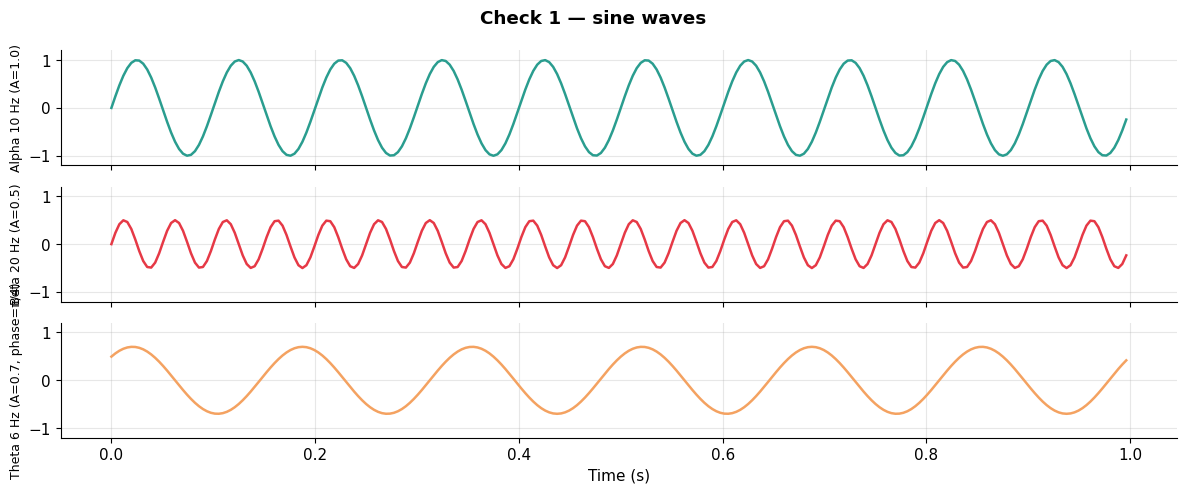

PASSED ✓


In [36]:
# ── SANITY CHECK 1 ─────────────────────────────────────────────────────────────
assert t          is not None, 'Build t'
assert alpha_wave is not None, 'Build alpha_wave'
assert len(t) == int(FS * DURATION),    f'Expected {int(FS*DURATION)} samples, got {len(t)}'
assert abs(t[0])  < 1e-9,               'Time vector should start at 0'
assert abs(t[1] - t[0] - 1/FS) < 1e-9, 'Time step should be 1/FS'
assert abs(alpha_wave[0])         < 1e-9,  'sin(0) = 0'
assert abs(np.max(alpha_wave) - 1.0) < 0.01, 'alpha amplitude should be 1.0'
assert abs(np.max(beta_wave)  - 0.5) < 0.01, 'beta amplitude should be 0.5'
assert abs(np.max(theta_wave) - 0.7) < 0.01, 'theta amplitude should be 0.7'

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for ax, wave, label, color in zip(axes,
    [alpha_wave, beta_wave, theta_wave],
    ['Alpha 10 Hz (A=1.0)', 'Beta 20 Hz (A=0.5)', 'Theta 6 Hz (A=0.7, phase=π/4)'],
    [BAND_COLORS['alpha'], BAND_COLORS['beta'], BAND_COLORS['theta']]):
    ax.plot(t[:FS], wave[:FS], color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(-1.2, 1.2)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Check 1 — sine waves', fontweight='bold')
plt.tight_layout()
plt.show()
print('PASSED ✓')

---
## Exercise 2 — Superposition

Real EEG is **never** a single clean sine wave. It is a sum of many oscillations at different frequencies, all happening simultaneously. This is called **superposition**.

Mathematically:
$$x_{\text{EEG}}(t) = \sum_{i} A_i \sin(2\pi f_i t + \phi_i) + \text{noise}$$

**The critical insight:** once you add multiple sine waves together, the resulting signal looks like a messy squiggle in the time domain. You **cannot** identify the individual frequencies just by looking at the raw trace. This is exactly why the FFT (Exercise 4) is so important — it automatically decomposes the mixture back into its components.

**Your task:** add the three waves into one composite signal.

In [37]:
def superpose(*waves):
    """
    Sum any number of signals together.

    Parameters
    ----------
    *waves : np.ndarray  — any number of arrays, all same shape

    Returns
    -------
    np.ndarray  — element-wise sum

    Pseudocode
    ----------
    result = zeros_like(waves[0])
    for each wave:
        result += wave
    return result
    """
    # ── YOUR CODE HERE ──
    return np.sum(waves,axis=0)


# ── YOUR CODE HERE ──
composite = superpose(alpha_wave,beta_wave,theta_wave)   # sum of alpha + beta + theta

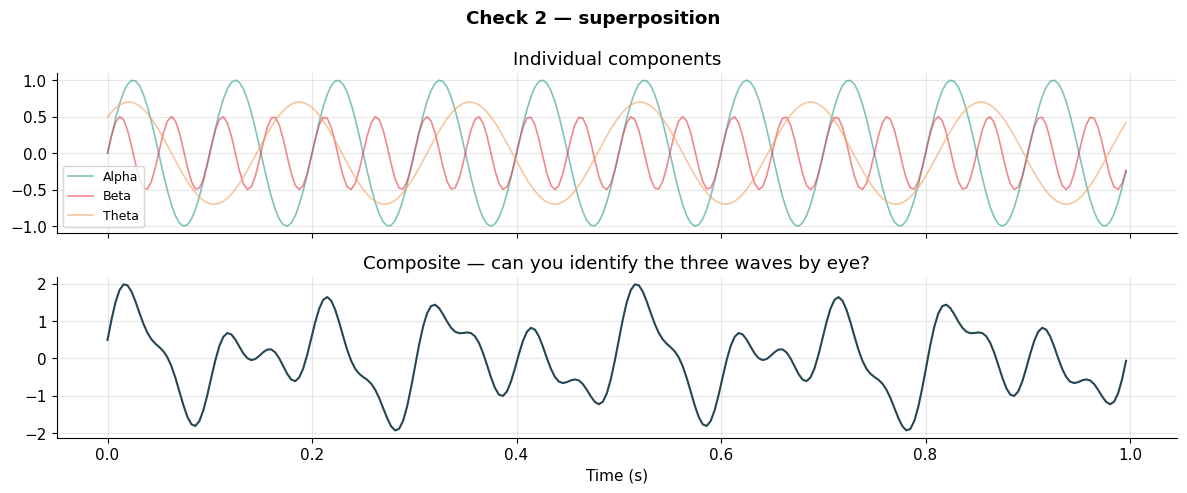

PASSED ✓


In [38]:
# ── SANITY CHECK 2 ─────────────────────────────────────────────────────────────
assert composite is not None, 'Build composite'
assert composite.shape == alpha_wave.shape, 'Shape mismatch'
expected_t0 = 0.0 + 0.0 + 0.7 * np.sin(np.pi / 4)
assert abs(composite[0] - expected_t0) < 0.01, \
    f'composite[0] ≈ {expected_t0:.3f}, got {composite[0]:.3f}'

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for wave, color, label in zip(
    [alpha_wave, beta_wave, theta_wave],
    [BAND_COLORS['alpha'], BAND_COLORS['beta'], BAND_COLORS['theta']],
    ['Alpha', 'Beta', 'Theta']):
    axes[0].plot(t[:FS], wave[:FS], alpha=0.6, linewidth=1.2, color=color, label=label)
axes[0].set_title('Individual components')
axes[0].legend(fontsize=9)
axes[1].plot(t[:FS], composite[:FS], color='#264653', linewidth=1.5)
axes[1].set_title('Composite — can you identify the three waves by eye?')
axes[1].set_xlabel('Time (s)')
fig.suptitle('Check 2 — superposition', fontweight='bold')
plt.tight_layout()
plt.show()
print('PASSED ✓')

---
## Exercise 3 — Add noise and compute SNR

### What is Gaussian white noise?

**White noise** has equal power at all frequencies — it is completely random with no structure. "Gaussian" means the noise values follow a Normal distribution with mean 0 and standard deviation $\sigma$ (noise_std).

In EEG, noise comes from: muscle movement, eye blinks, electrode drift, and 50/60 Hz power line interference. EEG has one of the worst signal-to-noise ratios of any biosignal.

### Signal-to-Noise Ratio (SNR)

SNR measures how strong your signal is relative to the background noise:

$$\text{SNR (dB)} = 10 \cdot \log_{10}\left(\frac{P_{\text{signal}}}{P_{\text{noise}}}\right)$$

**Breaking this down:**
- $P_{\text{signal}} = \frac{1}{N}\sum x_i^2$ — mean squared amplitude of the clean signal ("power")
- $P_{\text{noise}} = \frac{1}{N}\sum n_i^2$ — mean squared amplitude of the noise
- $\log_{10}$ compresses the ratio — doubling SNR in dB means 10× more power, not 2×
- The factor 10 is a convention: makes the unit "decibels (dB)"
- **Positive dB** → signal stronger than noise (good)
- **Negative dB** → noise stronger than signal (typical in raw EEG!)
- **0 dB** → signal and noise are equal strength

**Why mean squared?** Squaring ensures negative values count as much as positive ones — a sine wave has equal positive and negative parts, so mean amplitude would be zero, which is meaningless as a power measure.

In [39]:
def add_noise(sig, noise_std, seed=42):
    """
    Add zero-mean Gaussian white noise to a signal.

    Parameters
    ----------
    sig       : np.ndarray  — clean signal
    noise_std : float       — standard deviation σ of the noise
    seed      : int         — random seed for reproducibility

    Returns
    -------
    np.ndarray  — noisy signal, same shape as input

    Pseudocode
    ----------
    rng   = np.random.default_rng(seed)
    noise = rng.normal(loc=0, scale=noise_std, size=sig.shape)
    return sig + noise
    """
    # ── YOUR CODE HERE ──
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0,scale=noise_std,size=sig.shape)
    return sig+noise


def compute_snr_db(clean, noisy):
    """
    Compute Signal-to-Noise Ratio in decibels.

    Parameters
    ----------
    clean : np.ndarray  — original signal without noise
    noisy : np.ndarray  — signal with noise added

    Returns
    -------
    float  — SNR in dB

    Pseudocode
    ----------
    noise         = noisy - clean
    signal_power  = mean(clean ** 2)
    noise_power   = mean(noise ** 2)
    return 10 * log10(signal_power / noise_power)
    """
    # ── YOUR CODE HERE ──
    noise = noisy-clean
    return 10 *np.log10(np.mean(clean**2)/np.mean(noise**2))


# ── YOUR CODE HERE ──
noisy_low    = add_noise(composite,0.5)   # noise_std = 0.5
noisy_medium = add_noise(composite,1.5)   # noise_std = 1.5
noisy_high   = add_noise(composite,3.0)   # noise_std = 3.0

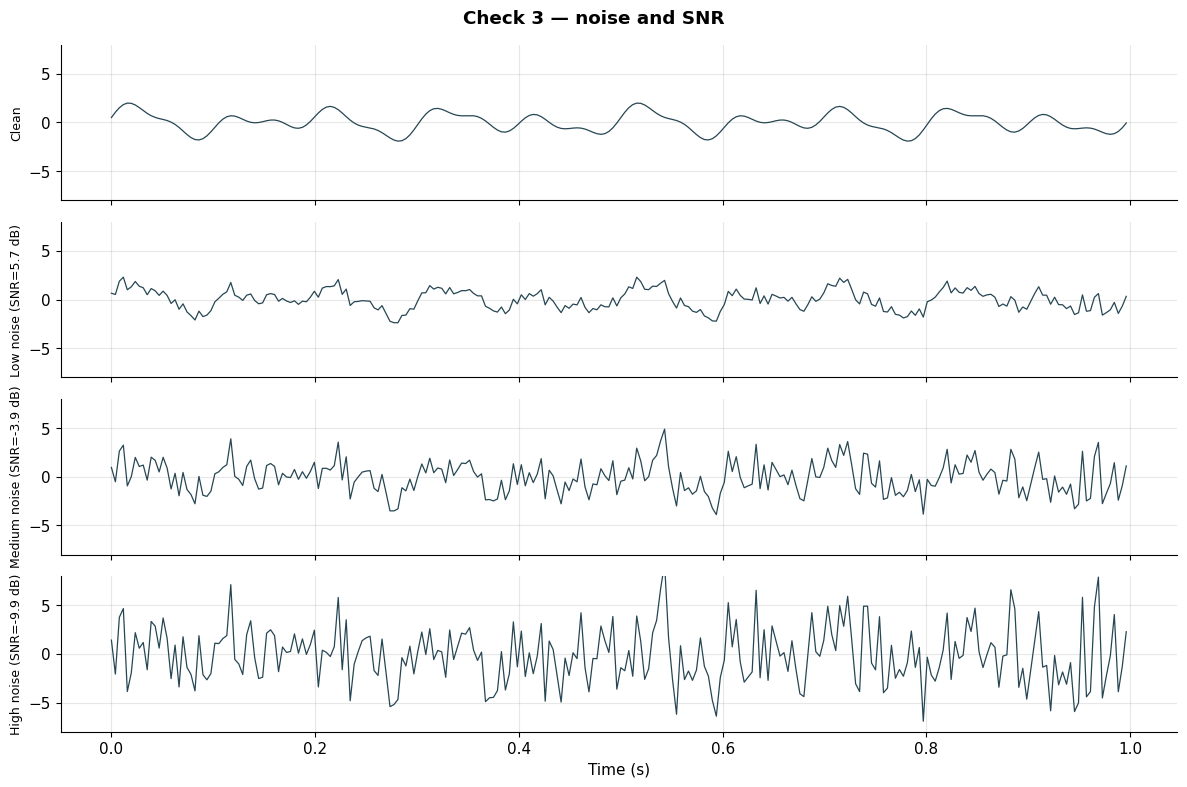

SNR: low=5.7 | medium=-3.9 | high=-9.9 dB
PASSED ✓


In [40]:
# ── SANITY CHECK 3 ─────────────────────────────────────────────────────────────
assert noisy_low    is not None, 'Build noisy_low'
assert noisy_medium is not None, 'Build noisy_medium'
assert noisy_high   is not None, 'Build noisy_high'
assert not np.allclose(noisy_low, composite), 'Noise not added'
assert abs((noisy_low - composite).std() - 0.5) < 0.05, 'noise_std should be ≈0.5'

snr_low    = compute_snr_db(composite, noisy_low)
snr_medium = compute_snr_db(composite, noisy_medium)
snr_high   = compute_snr_db(composite, noisy_high)
assert snr_low > snr_medium > snr_high, 'SNR must decrease as noise_std increases'
assert snr_low   > 0, 'Low noise  → positive SNR'
assert snr_high  < 0, 'High noise → negative SNR'

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, sig, label in zip(axes,
    [composite, noisy_low, noisy_medium, noisy_high],
    ['Clean', f'Low noise (SNR={snr_low:.1f} dB)',
     f'Medium noise (SNR={snr_medium:.1f} dB)',
     f'High noise (SNR={snr_high:.1f} dB)']):
    ax.plot(t[:FS], sig[:FS], color='#264653', linewidth=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(-8, 8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Check 3 — noise and SNR', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'SNR: low={snr_low:.1f} | medium={snr_medium:.1f} | high={snr_high:.1f} dB')
print('PASSED ✓')

---
## Exercise 4 — The Fast Fourier Transform (FFT)

### What is the FFT and why does it exist?

You just saw that superposing waves creates an unreadable mess in the time domain. The **Fourier Transform** solves this: it mathematically decomposes any signal into its component frequencies.

The **Fast Fourier Transform (FFT)** is an efficient algorithm that computes this decomposition. The result tells you: *at each frequency, how much energy is present?*

### What does `scipy.fft.fft()` return?

```python
from scipy.fft import fft, fftfreq
yf = fft(signal)   # input: (N,) real array
                   # output: (N,) complex array
```

The output is **complex numbers** — each has a real and imaginary part. You want the **magnitude** (how much energy at that frequency):
```python
magnitude = np.abs(yf)
```

### The frequency axis

```python
freqs = fftfreq(N, d=1/fs)
# N    = number of samples
# d    = time between samples = 1/fs
# returns: frequency in Hz for each FFT bin
```

`fftfreq` returns both positive and negative frequencies (the FFT is two-sided). For a real signal, the negative half is a mirror of the positive half — it carries no new information. We keep only the first half (`[:N//2]`).

### Why scale by `2/N`?

When we discard the negative half, we lose half the energy. Multiplying by 2 compensates. Dividing by N normalizes for signal length so the magnitude matches the original amplitude regardless of how long the signal is.

**Full procedure:**
```
N          = len(signal)
yf         = fft(signal)            → complex, shape (N,)
freqs      = fftfreq(N, 1/fs)       → Hz axis, shape (N,)
half       = N // 2
magnitudes = (2/N) * abs(yf[:half]) → one-sided magnitude, shape (half,)
freqs      = freqs[:half]           → only positive frequencies
```

### What does `sp_signal.find_peaks()` do?

```python
peak_indices, properties = sp_signal.find_peaks(array, height=threshold)
# array     : 1D array to search for peaks in
# height    : minimum value a point must have to count as a peak
# returns   : peak_indices — array of integer indices where peaks are
#             properties   — dict with peak heights etc. (we don't need this)
```

In [41]:
def compute_fft(sig, fs):
    """
    Compute one-sided FFT magnitude spectrum of a real signal.

    Parameters
    ----------
    sig : np.ndarray, shape (N,)  — input signal
    fs  : float                   — sampling rate in Hz

    Returns
    -------
    freqs      : np.ndarray, shape (N//2,)  — frequency axis in Hz
    magnitudes : np.ndarray, shape (N//2,)  — amplitude at each frequency

    Pseudocode
    ----------
    N          = len(sig)
    yf         = fft(sig)
    freqs_all  = fftfreq(N, 1/fs)
    half       = N // 2
    magnitudes = (2.0 / N) * abs(yf[:half])
    return freqs_all[:half], magnitudes
    """
    # ── YOUR CODE HERE ──
    N = len(sig)
    yf = fft(sig)
    freqs_all = fftfreq(N,1/fs)
    half = N//2
    magnitudes = (2.0/N)*abs(yf[:half])
    return freqs_all[:half],magnitudes

    


def find_peaks_fft(freqs, magnitudes, n_peaks=3, min_magnitude=0.1):
    """
    Find the dominant frequency peaks in an FFT magnitude spectrum.

    Parameters
    ----------
    freqs         : np.ndarray  — frequency axis
    magnitudes    : np.ndarray  — magnitudes
    n_peaks       : int         — how many peaks to return
    min_magnitude : float       — ignore peaks below this value

    Returns
    -------
    list of (freq_hz, magnitude) tuples, sorted by magnitude descending

    Pseudocode
    ----------
    peak_indices = sp_signal.find_peaks(magnitudes, height=min_magnitude)[0]
    sort peak_indices by magnitudes[peak_indices] descending
    keep top n_peaks
    return [(freqs[i], magnitudes[i]) for i in top_indices]
    """
    # ── YOUR CODE HERE ──
    peak_indices = sp_signal.find_peaks(magnitudes,height=min_magnitude)[0]
    sort_indices = peak_indices[np.argsort(magnitudes[peak_indices])[::-1]]
    top_indices = sort_indices[:n_peaks]
    return [(freqs[i], magnitudes[i]) for i in top_indices]

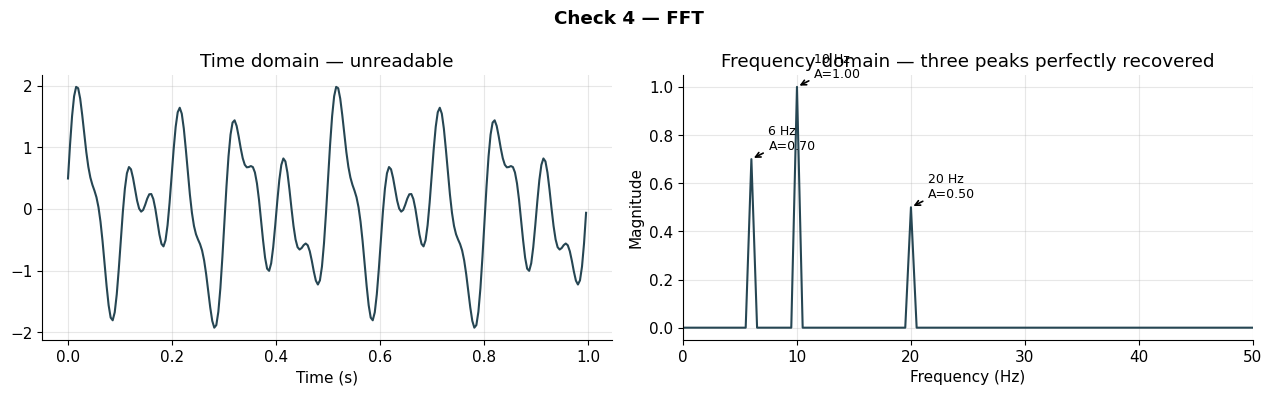

Peaks: [('10Hz', '1.00'), ('6Hz', '0.70'), ('20Hz', '0.50')]
PASSED ✓


In [42]:
# ── SANITY CHECK 4 ─────────────────────────────────────────────────────────────
freqs_c, mags_c = compute_fft(composite, FS)
assert freqs_c is not None and mags_c is not None, 'compute_fft returned None'
assert len(freqs_c) == len(composite) // 2, 'Expected N//2 frequency bins'
assert freqs_c[0] == 0.0, 'First bin = 0 Hz (DC component)'

peaks = find_peaks_fft(freqs_c, mags_c, n_peaks=3)
detected = sorted([round(p[0]) for p in peaks])
assert detected == [6, 10, 20], f'Expected [6, 10, 20] Hz, got {detected}'
peak_dict = {round(f): m for f, m in peaks}
assert abs(peak_dict[10] - 1.0) < 0.05, f'Alpha A ≈ 1.0, got {peak_dict[10]:.3f}'
assert abs(peak_dict[20] - 0.5) < 0.05, f'Beta  A ≈ 0.5, got {peak_dict[20]:.3f}'
assert abs(peak_dict[6]  - 0.7) < 0.05, f'Theta A ≈ 0.7, got {peak_dict[6]:.3f}'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t[:FS], composite[:FS], color='#264653', linewidth=1.5)
axes[0].set_title('Time domain — unreadable')
axes[0].set_xlabel('Time (s)')
axes[1].plot(freqs_c, mags_c, color='#264653', linewidth=1.5)
for freq, mag in peaks:
    axes[1].annotate(f'{freq:.0f} Hz\nA={mag:.2f}',
                     xy=(freq, mag), xytext=(freq+1.5, mag+0.04),
                     fontsize=9, arrowprops=dict(arrowstyle='->', lw=1.2))
axes[1].set_xlim(0, 50)
axes[1].set_title('Frequency domain — three peaks perfectly recovered')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
fig.suptitle('Check 4 — FFT', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Peaks: {[(f"{f:.0f}Hz", f"{m:.2f}") for f, m in peaks]}')
print('PASSED ✓')

---
## Exercise 5 — Band-pass filter

### What is a filter?

A **filter** removes unwanted frequencies and keeps wanted ones. Three types:
- **Low-pass**: keeps frequencies *below* a cutoff (e.g., remove high-frequency noise)
- **High-pass**: keeps frequencies *above* a cutoff (e.g., remove DC drift)
- **Band-pass**: keeps frequencies *between* two cutoffs — the most common in EEG

For motor imagery you typically apply:
1. A broad band-pass (0.5–45 Hz) to remove drift and very high noise
2. A narrower band-pass (8–30 Hz) to focus on mu and beta rhythms

### `scipy.signal.butter()` — the Butterworth filter

```python
b, a = sp_signal.butter(order, Wn, btype='band')
# order : int   — filter order. Higher = sharper cutoff, but more ringing
#                  Order 4 is the standard for EEG
# Wn    : list  — [low, high] cutoff frequencies, NORMALIZED to [0, 1]
#                  Normalized means: divide by Nyquist frequency (= fs/2)
#                  Example: 8 Hz with fs=256 → 8 / (256/2) = 8/128 = 0.0625
# btype : str   — 'band' for band-pass
# returns b, a  — filter coefficients (you pass these to filtfilt)
```

**Why normalize by Nyquist?** Butterworth works in normalized frequency space where 1.0 = the highest representable frequency (Nyquist). You must convert your Hz values into this space.

### `scipy.signal.filtfilt()` — zero-phase filtering

```python
filtered = sp_signal.filtfilt(b, a, signal)
# b, a   : filter coefficients from butter()
# signal : 1D array to filter
# returns: filtered signal, same shape
```

**Why `filtfilt` and not `lfilter`?**  
`lfilter` filters forward only → it shifts the signal in time (phase delay). A shifted signal means events are misaligned with brain activity — catastrophic for BCI.  
`filtfilt` filters forward then backward → the two phase shifts cancel to zero. **Always use `filtfilt` for EEG.**

### The Nyquist theorem

You can only measure frequencies up to $f_s / 2$ (the Nyquist frequency). With `fs=256 Hz`, the highest measurable frequency is 128 Hz. Your filter's `highcut` must be strictly below this. In practice, EEG content above 45 Hz is mostly noise, so we filter to 45 Hz.

In [43]:
def bandpass_filter(sig, lowcut, highcut, fs, order=4):
    """
    Apply a zero-phase Butterworth band-pass filter.

    Parameters
    ----------
    sig     : np.ndarray  — input signal
    lowcut  : float       — lower cutoff in Hz
    highcut : float       — upper cutoff in Hz
    fs      : float       — sampling rate in Hz
    order   : int         — filter order (default 4)

    Returns
    -------
    np.ndarray  — filtered signal, same shape as input

    Pseudocode
    ----------
    nyq  = fs / 2
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = sp_signal.butter(order, [low, high], btype='band')
    return sp_signal.filtfilt(b, a, sig)
    """
    # ── YOUR CODE HERE ──
    nyq = fs/2
    low = lowcut/nyq
    high = highcut/nyq
    b,a = sp_signal.butter(order,[low,high],btype='band')
    return sp_signal.filtfilt(b,a,sig)


# Filter noisy_medium through each EEG band
# Skip delta — its 0.5 Hz lower bound needs a much longer signal to be reliable
# ── YOUR CODE HERE ──
# filtered_bands: dict mapping band name → filtered np.ndarray
filtered_bands = {
    'alpha':bandpass_filter(alpha_wave,8,13,FS),
    'beta':bandpass_filter(beta_wave,13,30,FS)
}

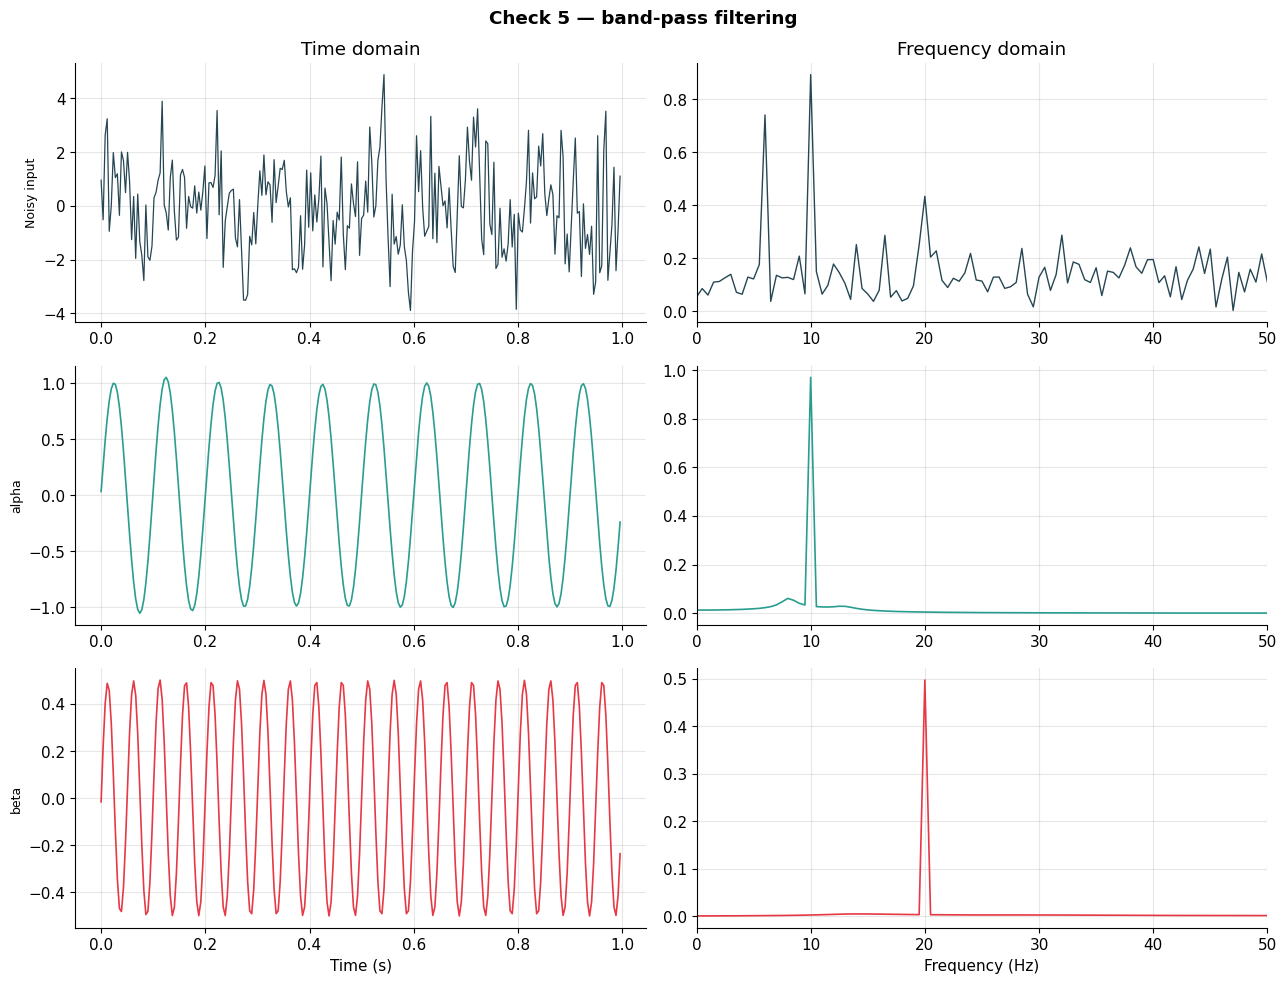

PASSED ✓


In [44]:
# ── SANITY CHECK 5 ─────────────────────────────────────────────────────────────
assert len(filtered_bands) > 0, 'filtered_bands is empty'
assert 'alpha' in filtered_bands, 'alpha band missing'
assert 'beta'  in filtered_bands, 'beta band missing'
f_a, m_a = compute_fft(filtered_bands['alpha'], FS)
f_b, m_b = compute_fft(filtered_bands['beta'],  FS)
assert 8  <= f_a[np.argmax(m_a)] <= 13, 'Alpha peak should be 8–13 Hz'
assert 13 <= f_b[np.argmax(m_b)] <= 30, 'Beta peak should be 13–30 Hz'

bands_plot = [b for b in ['theta','alpha','beta','gamma'] if b in filtered_bands]
fig, axes  = plt.subplots(len(bands_plot)+1, 2, figsize=(13, 10))
fig.suptitle('Check 5 — band-pass filtering', fontweight='bold')
axes[0,0].plot(t[:FS], noisy_medium[:FS], color='#264653', linewidth=0.9)
axes[0,0].set_ylabel('Noisy input', fontsize=9)
f_n, m_n = compute_fft(noisy_medium, FS)
axes[0,1].plot(f_n, m_n, color='#264653', linewidth=1.0)
axes[0,1].set_xlim(0,50)
for row, band in enumerate(bands_plot, 1):
    col = BAND_COLORS[band]
    f, m = compute_fft(filtered_bands[band], FS)
    axes[row,0].plot(t[:FS], filtered_bands[band][:FS], color=col, linewidth=1.2)
    axes[row,0].set_ylabel(band, fontsize=9)
    axes[row,1].plot(f, m, color=col, linewidth=1.2)
    axes[row,1].set_xlim(0,50)
axes[0,0].set_title('Time domain')
axes[0,1].set_title('Frequency domain')
axes[-1,0].set_xlabel('Time (s)')
axes[-1,1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()
print('PASSED ✓')

---
## Exercise 6 — Power Spectral Density (Welch's method)

### Why not just use the FFT for power analysis?

The raw FFT is noisy — if you run it twice on two segments of the same signal, you get different-looking spectra. This is because the FFT treats the signal as one long window, so any noise in that window directly distorts the result.

**Welch's method** solves this by averaging:
1. Split the signal into short, overlapping windows
2. Compute the FFT of each window
3. Square the magnitude → power (energy per frequency bin)
4. Average the power across all windows

More windows = smoother, more reliable estimate. This is the **Power Spectral Density (PSD)**.

### `scipy.signal.welch()` — the function you will use

```python
freqs, psd = sp_signal.welch(signal, fs=256, nperseg=256, noverlap=128)

# signal   : 1D array — your input signal
# fs       : sampling rate in Hz
# nperseg  : number of samples per window
#              larger → better frequency resolution (finer frequency axis)
#              smaller → more windows to average (smoother estimate)
#              rule of thumb: nperseg = fs gives 1 Hz resolution
# noverlap : samples of overlap between consecutive windows
#              None → defaults to nperseg // 2  (50% overlap)
#              more overlap → more windows → smoother PSD

# freqs : np.ndarray, shape (nperseg//2 + 1,) — frequency axis in Hz
#           goes from 0 Hz to fs/2 Hz
# psd   : np.ndarray, shape (nperseg//2 + 1,) — power at each frequency
#           units: amplitude² / Hz  (power density, not total power)
```

### Band power from PSD

To get the **total power within a frequency band** (e.g., alpha: 8–13 Hz), you integrate the PSD over that range:

$$P_{\text{band}} = \int_{f_{\text{low}}}^{f_{\text{high}}} \text{PSD}(f) \, df$$

Numerically, this is the trapezoidal rule: `np.trapz(psd[mask], freqs[mask])`
- `mask` selects only the frequency bins within the band
- `np.trapz(y, x)` approximates the area under the curve using trapezoids
- This gives you a single number: total power in that band

In [45]:
def compute_psd_welch(sig, fs, nperseg=256, noverlap=None):
    """
    Compute Power Spectral Density using Welch's method.

    Parameters
    ----------
    sig      : np.ndarray  — input signal
    fs       : float       — sampling rate in Hz
    nperseg  : int         — samples per window (default 256)
    noverlap : int|None    — overlap in samples (None → nperseg // 2)

    Returns
    -------
    freqs : np.ndarray  — frequency axis in Hz, range [0, fs/2]
    psd   : np.ndarray  — power density (amplitude² / Hz)

    Pseudocode
    ----------
    if noverlap is None:
        noverlap = nperseg // 2
    freqs, psd = sp_signal.welch(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return freqs, psd
    """
    # ── YOUR CODE HERE ──
    if noverlap is None:
        noverlap = nperseg // 2
    freqs,psd = sp_signal.welch(sig,fs,nperseg = nperseg,noverlap=noverlap)
    return freqs,psd


def band_power(freqs, psd, low, high):
    """
    Integrate PSD over a frequency band to get total band power.

    Parameters
    ----------
    freqs : np.ndarray  — frequency axis
    psd   : np.ndarray  — PSD values
    low   : float       — lower bound in Hz
    high  : float       — upper bound in Hz

    Returns
    -------
    float  — total power in the band

    Pseudocode
    ----------
    mask = (freqs >= low) & (freqs <= high)
    return np.trapz(psd[mask], freqs[mask])
    """
    # ── YOUR CODE HERE ──
    mask = (freqs >= low)&(freqs<=high)
    return np.trapz(psd[mask],freqs[mask])

/var/folders/ds/_jnmtffd60z_1pp9v59v1s0m0000gn/T/ipykernel_26878/881131295.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask],freqs[mask])


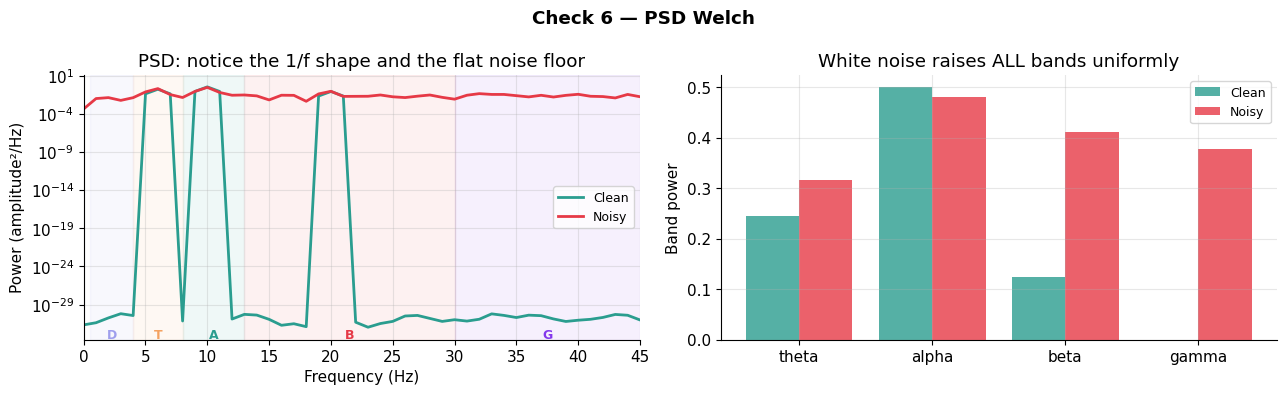

Alpha power=0.5000  Beta power=0.1250
PASSED ✓


In [46]:
# ── SANITY CHECK 6 ─────────────────────────────────────────────────────────────
f_psd, psd_clean = compute_psd_welch(composite,    FS, nperseg=256)
f_psd, psd_noisy = compute_psd_welch(noisy_medium, FS, nperseg=256)
assert f_psd    is not None, 'compute_psd_welch returned None'
assert f_psd[0] == 0.0,      'First bin should be 0 Hz'
assert f_psd[-1] == FS/2,    f'Last bin should be Nyquist {FS/2} Hz'

bp_alpha = band_power(f_psd, psd_clean, 8, 13)
bp_beta  = band_power(f_psd, psd_clean, 13, 30)
assert bp_alpha is not None, 'band_power returned None'
assert bp_alpha > bp_beta, 'Alpha power > beta power (alpha amplitude is larger)'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Check 6 — PSD Welch', fontweight='bold')
for psd, label, color in [(psd_clean,'Clean','#2A9D8F'),(psd_noisy,'Noisy','#E63946')]:
    axes[0].semilogy(f_psd, psd, label=label, color=color, linewidth=2)
for band,(lo,hi) in EEG_BANDS.items():
    axes[0].axvspan(lo, hi, alpha=0.07, color=BAND_COLORS[band])
    axes[0].text((lo+hi)/2, axes[0].get_ylim()[0]*1.5, band[0].upper(),
                 ha='center', fontsize=9, color=BAND_COLORS[band], fontweight='bold')
axes[0].set_xlim(0,45)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (amplitude²/Hz)')
axes[0].set_title('PSD: notice the 1/f shape and the flat noise floor')
axes[0].legend(fontsize=9)

band_names  = [b for b in EEG_BANDS if b != 'delta']
pw_clean = [band_power(f_psd, psd_clean, *EEG_BANDS[b]) for b in band_names]
pw_noisy = [band_power(f_psd, psd_noisy, *EEG_BANDS[b]) for b in band_names]
x = np.arange(len(band_names))
axes[1].bar(x-0.2, pw_clean, 0.4, label='Clean', color='#2A9D8F', alpha=0.8)
axes[1].bar(x+0.2, pw_noisy, 0.4, label='Noisy', color='#E63946', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_names)
axes[1].set_ylabel('Band power')
axes[1].set_title('White noise raises ALL bands uniformly')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Alpha power={bp_alpha:.4f}  Beta power={bp_beta:.4f}')
print('PASSED ✓')

---
## Exercise 7 — Spectrogram

### Why the PSD is not enough

Both the FFT and PSD assume the signal is **stationary** — the same frequency content throughout. EEG is not stationary: the brain changes what it is doing moment to moment. When someone starts imagining movement, their beta power drops. The PSD would average over the whole recording and you would miss this change.

A **spectrogram** solves this by computing a PSD for each short window of the signal and stacking them into a 2D image:
- **x-axis**: time
- **y-axis**: frequency
- **color**: power (how strong that frequency is at that time)

### `scipy.signal.spectrogram()` — the function

```python
f, t_seg, Sxx = sp_signal.spectrogram(signal, fs=256, nperseg=64, noverlap=56)

# signal   : 1D array — input signal
# fs       : sampling rate in Hz
# nperseg  : window length in samples
#              shorter window → better time resolution, worse frequency resolution
#              longer window  → worse time resolution, better frequency resolution
#              this is the fundamental time-frequency tradeoff
# noverlap : overlap between windows
#              higher overlap → more columns in Sxx, smoother-looking image

# f     : np.ndarray, shape (nperseg//2 + 1,) — frequency axis in Hz
# t_seg : np.ndarray, shape (T,)              — time axis in seconds
# Sxx   : np.ndarray, shape (F, T)            — power at each (freq, time) point
#   F = len(f), T = number of windows
#   Sxx[i, j] = power at frequency f[i] at time t_seg[j]
```

### Displaying with `pcolormesh`

`plt.pcolormesh(t_seg, f, Sxx)` makes the 2D color plot. We usually display `10 * log10(Sxx)` — converting power to decibels — because the range of values spans several orders of magnitude and a log scale makes the structure visible.

### Your task

Build a 6-second signal that changes over time:  
- 0–2s: rest → strong alpha (10 Hz) + theta (6 Hz)  
- 2–4s: motor imagery → **alpha suppressed** (ERD), only theta remains  
- 4–6s: rest → alpha returns  

Then compute the spectrogram and verify visually that alpha disappears in the middle segment.

In [47]:
def compute_spectrogram(sig, fs, nperseg=64, noverlap=56):
    """
    Compute a spectrogram (time-frequency power map).

    Parameters
    ----------
    sig      : np.ndarray  — input signal
    fs       : float       — sampling rate in Hz
    nperseg  : int         — window length in samples (default 64)
    noverlap : int         — overlap in samples (default 56 = 87.5%)

    Returns
    -------
    f     : np.ndarray, shape (F,)    — frequency axis in Hz
    t_seg : np.ndarray, shape (T,)    — time axis in seconds
    Sxx   : np.ndarray, shape (F, T)  — power at each (freq, time)

    Pseudocode
    ----------
    f, t_seg, Sxx = sp_signal.spectrogram(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return f, t_seg, Sxx
    """
    # ── YOUR CODE HERE ──
    f,t_seg,Sxx = sp_signal.spectrogram(sig,fs,nperseg=nperseg,noverlap=noverlap)
    return f, t_seg,Sxx


# Build the non-stationary 6-second trial
# Hint: build three 2-second segments using make_sine() and add_noise(),
#       then np.concatenate() them.
# Rest segments:  theta (6Hz, A=0.8) + alpha (10Hz, A=1.2) + noise(std=0.5)
# Imagery segment: theta (6Hz, A=0.8) + alpha (10Hz, A=0.15) + noise(std=0.5)

T_long  = 6.0
t_long  = np.linspace(0, T_long, int(FS * T_long), endpoint=False)
t_seg2  = t_long[:int(FS * 2)]   # 2-second time vector for each segment

# ── YOUR CODE HERE ──
seg1 = make_sine(t_seg2,10,1.2)+make_sine(t_seg2,6,0.8)
seg1 = add_noise(seg1,0.5)
seg2 = make_sine(t_seg2,10,0.15)+make_sine(t_seg2,6,0.8)
seg2 = add_noise(seg2,0.5)
seg3 = make_sine(t_seg2,10,1.2)+make_sine(t_seg2,6,0.8)
seg3 = add_noise(seg3,0.5)
trial_signal = np.concatenate([seg1,seg2,seg3])

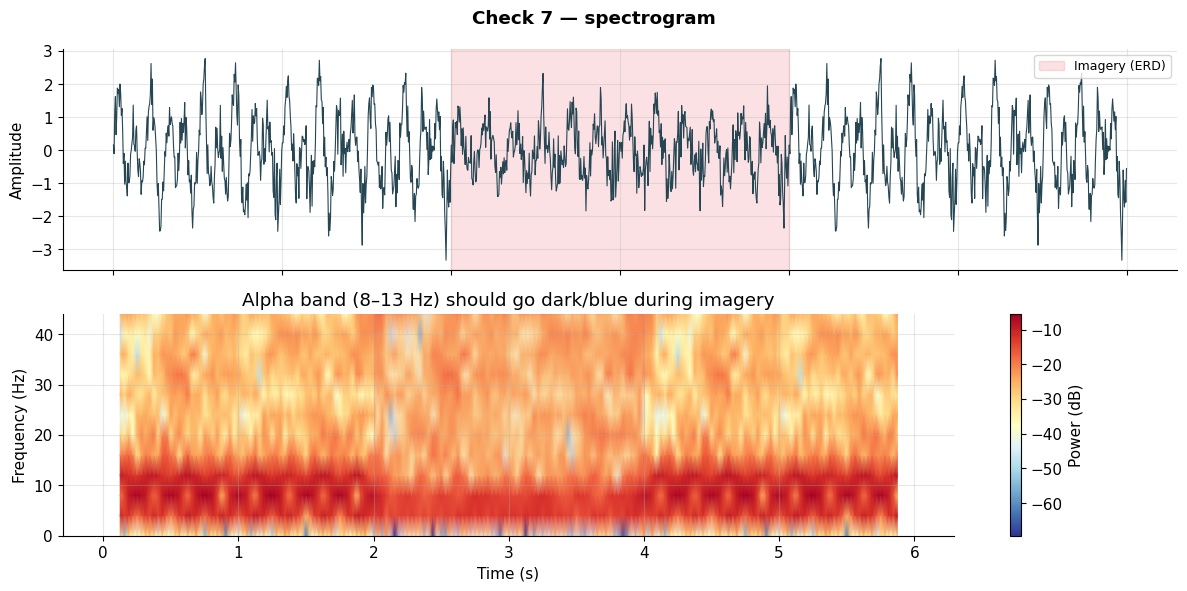

Alpha power — rest: 0.09718 | imagery: 0.02624
PASSED ✓


In [48]:
# ── SANITY CHECK 7 ─────────────────────────────────────────────────────────────
assert trial_signal is not None, 'Build trial_signal'
assert len(trial_signal) == int(FS * T_long), \
    f'Expected {int(FS*T_long)} samples, got {len(trial_signal)}'

f_sp, t_sp, Sxx = compute_spectrogram(trial_signal, FS, nperseg=64, noverlap=56)
assert Sxx is not None,               'compute_spectrogram returned None'
assert Sxx.shape[0] == len(f_sp),     'Rows must match frequency axis'
assert Sxx.shape[1] == len(t_sp),     'Cols must match time axis'

alpha_mask = (f_sp >= 8) & (f_sp <= 13)
alpha_rest  = Sxx[alpha_mask][:, t_sp <  2].mean()
alpha_imag  = Sxx[alpha_mask][:, (t_sp >= 2) & (t_sp < 4)].mean()
assert alpha_imag < alpha_rest, \
    'Alpha power must be lower during imagery — check your signal construction'

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Check 7 — spectrogram', fontweight='bold')
axes[0].plot(t_long, trial_signal, color='#264653', linewidth=0.8)
axes[0].axvspan(2, 4, alpha=0.15, color='#E63946', label='Imagery (ERD)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9, loc='upper right')
fm = f_sp <= 45
im = axes[1].pcolormesh(t_sp, f_sp[fm], 10*np.log10(Sxx[fm]+1e-12),
                         shading='gouraud', cmap='RdYlBu_r')
axes[1].axvspan(2, 4, alpha=0.15, color='#E63946')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Alpha band (8–13 Hz) should go dark/blue during imagery')
plt.colorbar(im, ax=axes[1], label='Power (dB)')
plt.tight_layout()
plt.show()
print(f'Alpha power — rest: {alpha_rest:.5f} | imagery: {alpha_imag:.5f}')
print('PASSED ✓')

---
## Exercise 8 — ERD: the motor imagery signature

### What is ERD?

**Event-Related Desynchronization (ERD)** is the single most important phenomenon in motor imagery BCI. When a person imagines moving their hand, power in the **mu rhythm (8–12 Hz)** and **beta band (13–30 Hz)** *decreases* over the corresponding motor cortex.

This is counter-intuitive — brain *activity* shows up as power *decrease*. The reason is that synchronized, idle neurons produce large rhythmic oscillations (high power). When those neurons engage in computation, they desynchronize — smaller, irregular activity — so power drops.

### The ERD formula

$$\text{ERD}(f, t) = 100 \times \frac{P(f,t) - P_{\text{baseline}}(f)}{P_{\text{baseline}}(f)}$$

**Breaking this down:**
- $P(f, t)$: power at frequency $f$ at time $t$ — one cell of your spectrogram matrix `Sxx`
- $P_{\text{baseline}}(f)$: **average** power at frequency $f$ during the pre-stimulus window (before the cue). This is your reference — what the brain looks like at rest
- The subtraction $(P - P_{\text{baseline}})$: how much did power change from baseline?
- Dividing by $P_{\text{baseline}}$: normalizes so results are comparable across frequencies and subjects (frequencies differ hugely in raw power due to the 1/f shape)
- Multiplying by 100: gives percentage change
- **ERD = −50%** means power dropped to half of baseline → strong brain engagement
- **ERD = +30%** means power increased 30% above baseline → event-related synchronization (ERS)

**Computing baseline:** take all time columns of `Sxx` where `t_spec <= baseline_tmax`, then average across those columns for each frequency row. This gives a vector of shape `(F, 1)` — one baseline power value per frequency.

In [49]:
def simulate_eeg_trial(t, mu_amp, beta_amp, noise_std=0.8, seed=0):
    """
    Simulate an EEG-like trial with controllable mu and beta power.

    Parameters
    ----------
    t         : np.ndarray  — time vector
    mu_amp    : float       — amplitude of mu rhythm (simulates 10 Hz)
    beta_amp  : float       — amplitude of beta rhythm (simulates 20 Hz)
    noise_std : float       — noise standard deviation
    seed      : int         — random seed

    Returns
    -------
    np.ndarray  — simulated EEG-like signal

    Pseudocode
    ----------
    rng   = np.random.default_rng(seed)
    delta = make_sine(t, 2,  amplitude=2.0, phase=rng.uniform(0, np.pi))
    theta = make_sine(t, 6,  amplitude=1.0, phase=rng.uniform(0, np.pi))
    mu    = make_sine(t, 10, amplitude=mu_amp,   phase=rng.uniform(0, np.pi))
    beta  = make_sine(t, 20, amplitude=beta_amp, phase=rng.uniform(0, np.pi))
    noise = noise_std * rng.standard_normal(len(t))
    return delta + theta + mu + beta + noise
    """
    # ── YOUR CODE HERE ──
    rng = np.random.default_rng(seed)
    delta = make_sine(t,2,amplitude=2.0,phase=rng.uniform(0,np.pi))
    theta = make_sine(t,6,amplitude=1.0,phase=rng.uniform(0,np.pi))
    mu = make_sine(t,10,amplitude=mu_amp,phase=rng.uniform(0,np.pi))
    beta = make_sine(t,20,amplitude=beta_amp,phase = rng.uniform(0,np.pi))
    noise = noise_std*rng.standard_normal(len(t))
    return delta+theta+mu+beta+noise

def compute_erd(Sxx, t_spec, baseline_tmax=0.0):
    """
    Compute ERD (%) from a spectrogram relative to a pre-event baseline.

    Parameters
    ----------
    Sxx           : np.ndarray, shape (F, T)  — spectrogram power matrix
    t_spec        : np.ndarray, shape (T,)    — time axis in seconds
    baseline_tmax : float  — use columns where t_spec <= this as baseline

    Returns
    -------
    erd : np.ndarray, shape (F, T)  — ERD % at each (freq, time)

    Pseudocode
    ----------
    bl_mask  = t_spec <= baseline_tmax           # boolean mask for baseline cols
    baseline = Sxx[:, bl_mask].mean(axis=1, keepdims=True)  # shape (F, 1)
    erd      = 100 * (Sxx - baseline) / (baseline + 1e-30)  # avoid div by zero
    return erd
    """
    # ── YOUR CODE HERE ──
    bl_mask = t_spec <=baseline_tmax
    baseline = Sxx[:,bl_mask].mean(axis=1,keepdims=True)
    erd = 100*(Sxx-baseline)/(baseline+1e-30)
    return erd


# Build a 4-second trial:
#   0.0 – 0.5s : baseline (rest)  → mu_amp=1.5, beta_amp=0.8
#   0.5 – 4.0s : imagery          → mu_amp=0.3, beta_amp=0.2  (ERD)
# Hint: build two segments (0.5s baseline, 3.5s imagery), concatenate

# ── YOUR CODE HERE ──
t_base = np.linspace(0,0.5,int(0.5*FS),endpoint=False)
t_imag = np.linspace(0,3.5,int(3.5*FS),endpoint=False)
baseline_seg = simulate_eeg_trial(t_base,mu_amp=1.5,beta_amp=0.8)
imag_seg = simulate_eeg_trial(t_imag,mu_amp=0.3,beta_amp=0.2)
t_trial   = t_trial = np.linspace(0, 4.0, int(FS * 4.0), endpoint=False)   # 4-second time vector
eeg_trial = np.concatenate([baseline_seg,imag_seg])   # concatenated baseline + imagery

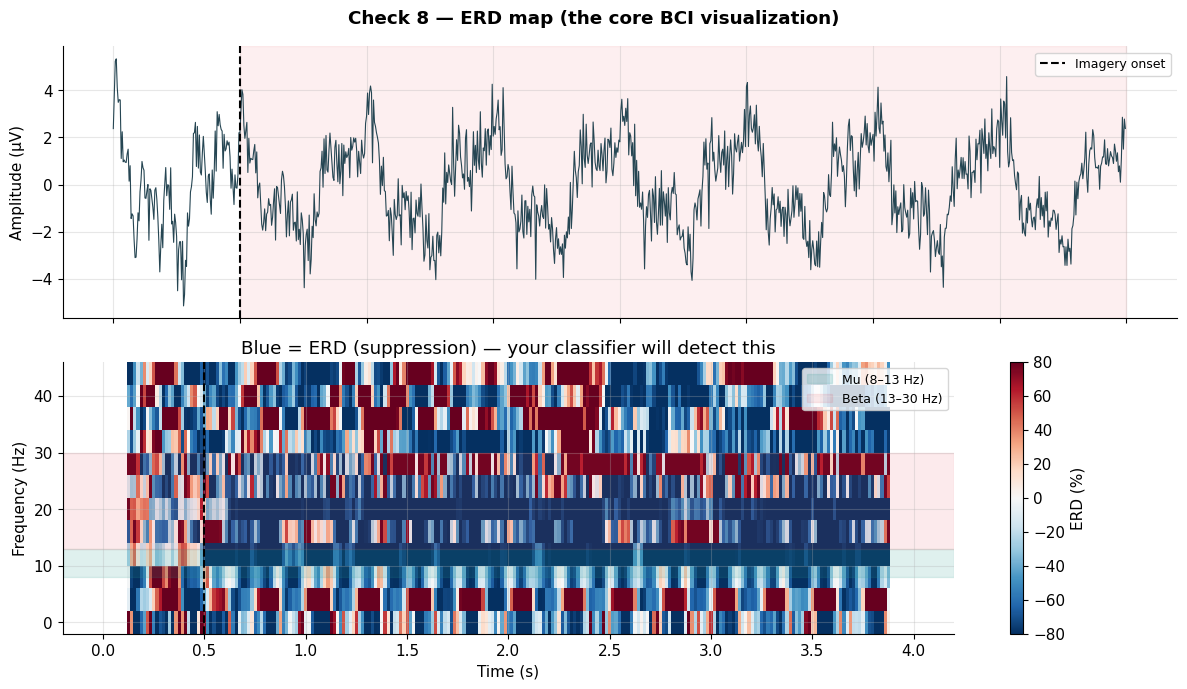

Mean ERD during imagery (mu band): -65.5%
PASSED ✓

Part 1 complete. You have implemented every signal processing tool
used in real EEG analysis pipelines. Part 2 applies them to real data.


In [50]:
# ── SANITY CHECK 8 ─────────────────────────────────────────────────────────────
assert eeg_trial is not None, 'Build eeg_trial'
assert len(eeg_trial) == int(FS * 4.0), f'Expected {int(FS*4)} samples'

f_e, t_e, Sxx_e = compute_spectrogram(eeg_trial, FS, nperseg=64, noverlap=60)
erd_map = compute_erd(Sxx_e, t_e, baseline_tmax=0.5)
assert erd_map is not None,                  'compute_erd returned None'
assert erd_map.shape == Sxx_e.shape,         'ERD shape must match Sxx'

mu_mask  = (f_e >= 8) & (f_e <= 13)
erd_mean = erd_map[mu_mask][:, t_e > 0.5].mean()
assert erd_mean < 0, f'Mean ERD should be negative during imagery, got {erd_mean:.1f}%'

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Check 8 — ERD map (the core BCI visualization)', fontweight='bold')
axes[0].plot(t_trial, eeg_trial, color='#264653', linewidth=0.8)
axes[0].axvline(0.5, color='black', linewidth=1.5, linestyle='--', label='Imagery onset')
axes[0].axvspan(0.5, 4.0, alpha=0.08, color='#E63946')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].legend(fontsize=9)
fm = f_e <= 45
im = axes[1].pcolormesh(t_e, f_e[fm], erd_map[fm],
                         cmap='RdBu_r', vmin=-80, vmax=80, shading='auto')
axes[1].axvline(0.5, color='black', linewidth=1.5, linestyle='--')
axes[1].axhspan(8,  13, alpha=0.15, color='#2A9D8F', label='Mu (8–13 Hz)')
axes[1].axhspan(13, 30, alpha=0.10, color='#E63946', label='Beta (13–30 Hz)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Blue = ERD (suppression) — your classifier will detect this')
axes[1].legend(fontsize=9, loc='upper right')
plt.colorbar(im, ax=axes[1], label='ERD (%)')
plt.tight_layout()
plt.show()
print(f'Mean ERD during imagery (mu band): {erd_mean:.1f}%')
print('PASSED ✓')
print()
print('Part 1 complete. You have implemented every signal processing tool')
print('used in real EEG analysis pipelines. Part 2 applies them to real data.')

---
---
# Part 2 — Real EEG data with MNE-Python

## Background: what is MNE-Python?

**MNE-Python** is the standard library for EEG/MEG analysis in Python, used in both academia and industry BCI work. It provides:
- File I/O for all common EEG formats (GDF, EDF, BDF, FIF, ...)
- The `Raw` object: a container for continuous EEG + its metadata (sampling rate, channel names, events)
- The `Epochs` object: a collection of fixed-length signal segments cut around events
- Preprocessing tools: filtering, re-referencing, artifact rejection
- Visualization: raw traces, PSD, topomaps, time-frequency plots

**Install:**
```bash
pip install mne scipy matplotlib numpy
```

## The dataset: BCI Competition IV Dataset 2a

- 9 subjects, 4 motor imagery classes: **left hand (769), right hand (770), feet (771), tongue (772)**
- 22 EEG channels + 3 EOG channels
- Sampling rate: **250 Hz**
- 288 trials per subject (training) + 288 (test)
- File format: GDF (General Data Format — common in BCI)

**Trial structure:**
```
t = 0s   → fixation cross appears
t = 2s   → cue appears (arrow pointing left/right/down) — motor imagery starts here
t = 6s   → trial ends
```
We will epoch from **-0.5s to +4s** relative to the cue (t=2s mark).

**Get the data:**  
Option A (recommended): use MOABB for automatic download:
```python
# pip install moabb
from moabb.datasets import BNCI2014001
dataset = BNCI2014001()
dataset.download()
```
Option B: register (free) at http://www.bbci.de/competition/iv/ and download manually.  
Place files in `./data/` next to this notebook. You need: `A01T.gdf`, `A01T.mat`.

In [51]:
# dowaload .mat data (the .gdf data needs downloading mannualy)
# from moabb.datasets.bnci import BNCI2014001
# dataset = BNCI2014001()
# dataset.download()

In [52]:
import mne
mne.set_log_level('WARNING')

DATA_DIR   = 'mne_data/001-2014'
SUBJECT    = 'A01'
TRAIN_GDF  = os.path.join(DATA_DIR, f'{SUBJECT}T.gdf')
LABEL_MAT  = os.path.join(DATA_DIR, f'{SUBJECT}T.mat')

CLASS_NAMES  = {1:'left_hand', 2:'right_hand', 3:'feet', 4:'tongue'}
CLASS_COLORS = {1:'#2A9D8F', 2:'#E63946', 3:'#F4A261', 4:'#9F9FED'}

print(f'GDF file exists : {os.path.exists(TRAIN_GDF)}')
print(f'MAT file exists : {os.path.exists(LABEL_MAT)}')

GDF file exists : True
MAT file exists : True


---
## Exercise 9 — Load the GDF file and inspect it

### `mne.io.read_raw_gdf()` — loading EEG from a GDF file

```python
raw = mne.io.read_raw_gdf(fname, stim_channel='auto', preload=True)

# fname         : str   — path to the .gdf file
# stim_channel  : str   — 'auto' lets MNE find the stimulus/event channel automatically
# preload       : bool  — True loads all data into RAM immediately
#                         False reads from disk on demand (use for very large files)

# returns: Raw object
```

### The `Raw` object — what's inside?

```python
raw.info           # dict-like: sampling rate, channel names, channel types, ...
raw.info['sfreq']  # sampling frequency in Hz
raw.ch_names       # list of channel name strings
raw.n_times        # total number of time samples
raw.times          # time array in seconds, shape (n_times,)

# Indexing: raw[channels, samples] → (data, times)
data, times = raw[0:3, :1000]  # first 3 channels, first 1000 samples
# data shape: (n_channels, n_samples), units: Volts (multiply by 1e6 for μV)
```

### Your task
Load the raw file and print: sampling rate, number of channels, duration in seconds, and all channel names.

In [53]:
# ── YOUR CODE HERE ──
# Load the GDF file with preload=True
# Print: raw.info['sfreq'], len(raw.ch_names), raw.times[-1], raw.ch_names
raw = mne.io.read_raw_gdf(os.path.join(DATA_DIR,'A07T.gdf'),stim_channel='auto',preload=True)

/opt/miniconda3/envs/eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [54]:
# ── SANITY CHECK 9 ─────────────────────────────────────────────────────────────
assert raw is not None, 'Load the raw file'
assert raw.info['sfreq'] == 250.0, \
    f'Dataset 2a sampling rate should be 250 Hz, got {raw.info["sfreq"]}'
assert len(raw.ch_names) >= 22, \
    f'Expected at least 22 channels, got {len(raw.ch_names)}'
assert raw.times[-1] > 100, 'Recording should be longer than 100 seconds'

print('=== Raw object summary ===')
print(f'Sampling rate : {raw.info["sfreq"]} Hz')
print(f'Channels      : {len(raw.ch_names)}')
print(f'Duration      : {raw.times[-1]:.1f} s ({raw.times[-1]/60:.1f} min)')
print(f'Total samples : {raw.n_times}')
print(f'Channel names : {raw.ch_names}')
print('PASSED ✓')

=== Raw object summary ===
Sampling rate : 250.0 Hz
Channels      : 25
Duration      : 2724.3 s (45.4 min)
Total samples : 681071
Channel names : ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
PASSED ✓


---
## Exercise 10 — Assign montage and preprocess

### What is a montage and why do we need it?

A **montage** tells MNE the physical 3D location of each electrode on the scalp. Without it, MNE has no idea where electrodes are, and visualization tools like `plot_topomap()` will fail.

The standard **10-20 system** defines named electrode positions covering the scalp. Dataset 2a uses 22 of these positions:
```
Fz, FC3, FC1, FCz, FC2, FC4,
C5, C3, C1, Cz, C2, C4, C6,
CP3, CP1, CPz, CP2, CP4,
P1, Pz, P2, POz
```
The GDF file names them generically (EEG1, EEG2...). We rename them first.

### Key MNE functions here

```python
# 1. Rename channels
raw.rename_channels({'EEG1': 'Fz', 'EEG2': 'FC3', ...})

# 2. Set channel types (EEG vs EOG)
raw.set_channel_types({'EOG1': 'eog', 'EOG2': 'eog', 'EOG3': 'eog'})

# 3. Apply standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')
# match_case=False  : ignore capitalization differences
# on_missing='ignore': skip channels not in the standard montage (e.g. rare positions)

# 4. Keep only EEG channels
raw_eeg = raw.copy().pick_types(eeg=True)
# .copy() is important — it avoids modifying raw in place
# pick_types(eeg=True) drops EOG, stim, and other non-EEG channels

# 5. Band-pass filter (MNE calls filtfilt internally)
raw_eeg.filter(l_freq=0.5, h_freq=45.0)
# l_freq : lower cutoff — removes DC drift (slow wandering)
# h_freq : upper cutoff — removes high-frequency muscle noise

# 6. Average reference
raw_eeg.set_eeg_reference('average', projection=False)
# Subtracts the mean across all electrodes from each electrode
# Standard for motor imagery — removes noise common to all channels
# projection=False applies it immediately (vs storing as a projector)
```

In [55]:
# Standard 10-20 names for Dataset 2a (in order)
EEG_CH_NAMES = [
    'Fz',
    'FC3','FC1','FCz','FC2','FC4',
    'C5','C3','C1','Cz','C2','C4','C6',
    'CP3','CP1','CPz','CP2','CP4',
    'P1','Pz','P2','POz'
]

# ── YOUR CODE HERE ──
# Step 1: Find EEG channels in raw.ch_names (those containing 'EEG')
print(raw.ch_names)
# Step 2: Build rename dict mapping old names → EEG_CH_NAMES
rename_map = {
    'EEG-Fz'      : 'Fz',
    'EEG-0'       : 'FC3',
    'EEG-1'       : 'FC1',
    'EEG-2'       : 'FCz',
    'EEG-3'       : 'FC2',
    'EEG-4'       : 'FC4',
    'EEG-5'       : 'C5',
    'EEG-C3'      : 'C3',
    'EEG-6'       : 'C1',
    'EEG-Cz'      : 'Cz',
    'EEG-7'       : 'C2',
    'EEG-C4'      : 'C4',
    'EEG-8'       : 'C6',
    'EEG-9'       : 'CP3',
    'EEG-10'      : 'CP1',
    'EEG-11'      : 'CPz',
    'EEG-12'      : 'CP2',
    'EEG-13'      : 'CP4',
    'EEG-14'      : 'P1',
    'EEG-Pz'      : 'Pz',
    'EEG-15'      : 'P2',
    'EEG-16'      : 'POz',
    'EOG-left'    : 'EOG1',
    'EOG-central' : 'EOG2',
    'EOG-right'   : 'EOG3',
}
# Step 3: raw.rename_channels(rename_dict)
raw.rename_channels(rename_map)
# Step 4: Set EOG channel types
raw.set_channel_types({'EOG1':'eog','EOG2':'eog','EOG3':'eog'})
# Step 5: Set montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage,match_case=False,on_missing='ignore')
# Step 6: raw_eeg = raw.copy().pick_types(eeg=True)
raw_eeg = raw.copy().pick_types(eeg=True)
# Step 7: filter 0.5–45 Hz
raw_eeg.filter(l_freq = 0.5,h_freq = 45)
# Step 8: average reference

raw_eeg.set_eeg_reference('average',projection = False)

['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']


<RawGDF | A07T.gdf, 22 x 681071 (2724.3 s), ~114.4 MiB, data loaded>

In [56]:
# ── SANITY CHECK 10 ────────────────────────────────────────────────────────────
assert raw_eeg is not None, 'Build raw_eeg'
assert len(raw_eeg.ch_names) == 22, \
    f'Expected 22 EEG channels after picking, got {len(raw_eeg.ch_names)}'
assert 'C3' in raw_eeg.ch_names, 'C3 should be in ch_names after renaming'
assert 'C4' in raw_eeg.ch_names, 'C4 should be in ch_names after renaming'
assert 'Cz' in raw_eeg.ch_names, 'Cz should be in ch_names after renaming'

# Montage check — positions should not be None
pos = raw_eeg.info['chs'][0]['loc'][:3]
assert not np.allclose(pos, 0), 'Montage not set — electrode positions are all zero'

print('Channels after preprocessing:', raw_eeg.ch_names)
print(f'Sampling rate: {raw_eeg.info["sfreq"]} Hz')
print('PASSED ✓')

Channels after preprocessing: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
Sampling rate: 250.0 Hz
PASSED ✓


---
## Exercise 11 — Plot raw EEG traces

### How to extract data from a `Raw` object

```python
data, times = raw_eeg[channel_list, :]  
# channel_list : list of channel name strings — e.g. ['C3', 'Cz', 'C4']
# :            : all time points
# data shape   : (n_channels, n_times)
# units        : Volts — multiply by 1e6 to get μV
```

To select a time window, convert seconds to sample indices:
```python
fs       = raw_eeg.info['sfreq']
idx_start = int(t_start * fs)
idx_end   = int(t_end   * fs)
data_window = data[:, idx_start:idx_end]   # shape (n_channels, window_samples)
```

### Your task
Plot a 5-second window (10–15 s) of raw EEG for these motor-relevant channels:
`['C3', 'Cz', 'C4', 'FC3', 'FCz', 'FC4', 'CP3', 'CPz', 'CP4']`

One channel per subplot row. Remember to convert Volts → μV.

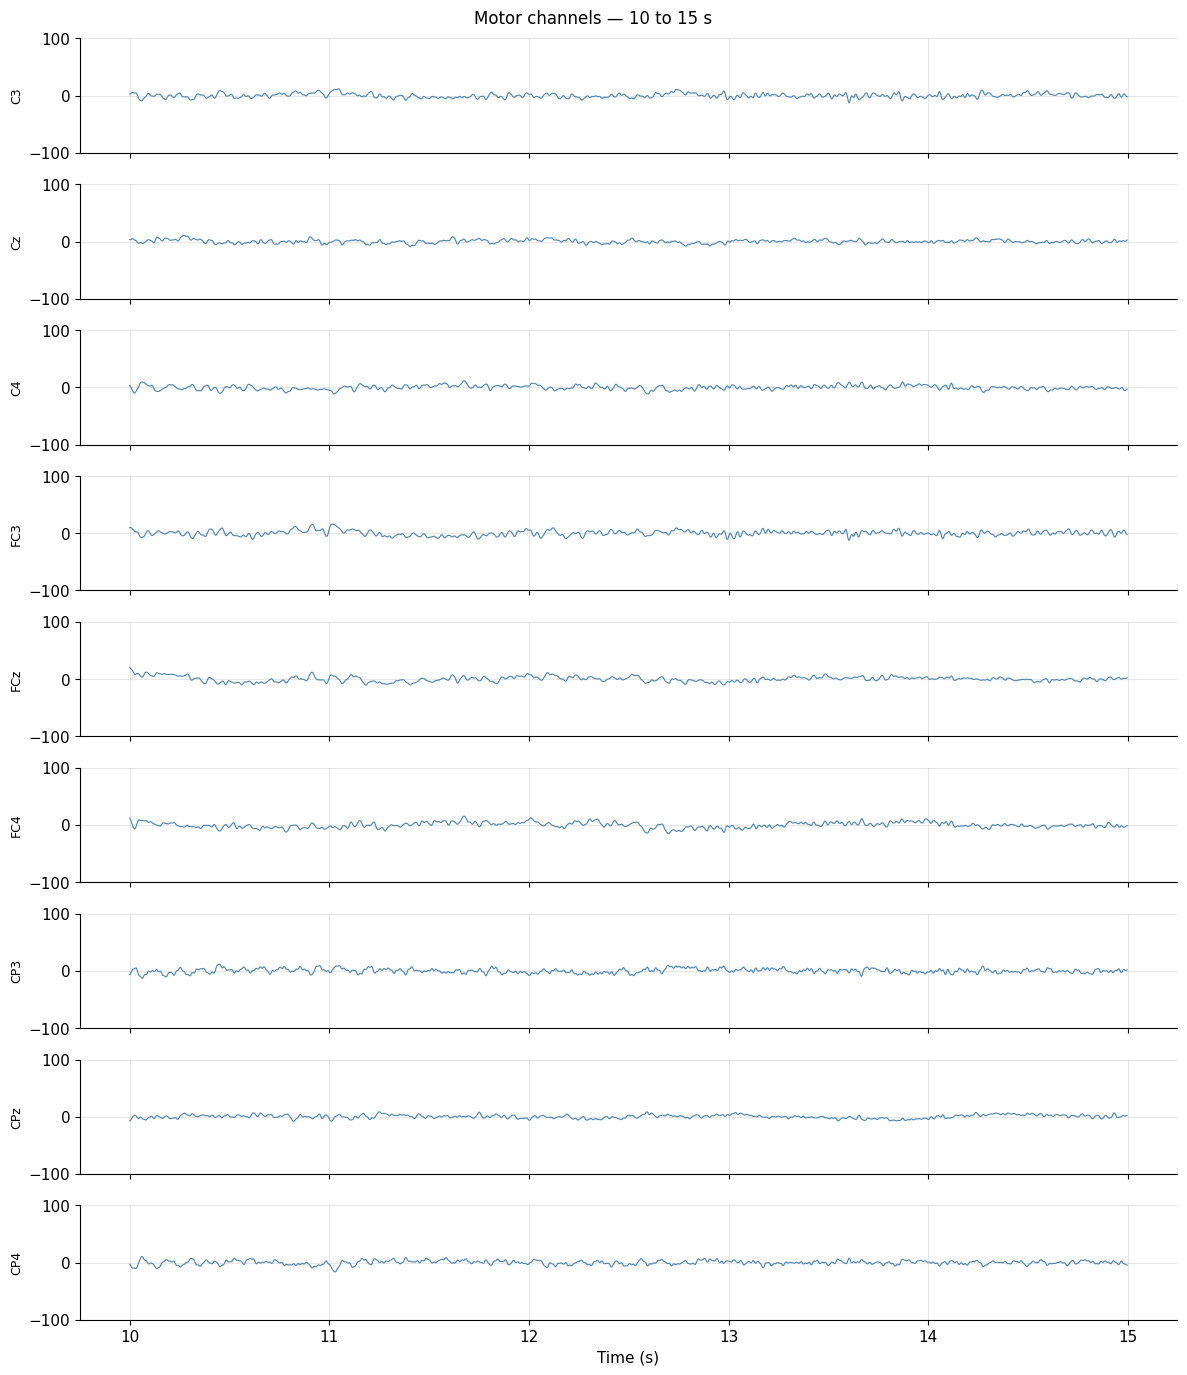

In [57]:
MOTOR_CHANNELS = ['C3','Cz','C4','FC3','FCz','FC4','CP3','CPz','CP4']

# ── YOUR CODE HERE ──
# 1. Extract data and times for MOTOR_CHANNELS
data,times = raw_eeg[MOTOR_CHANNELS,:]
# 2. Select time window 10–15s (convert to sample indices)
fs = raw_eeg.info['sfreq']
data_window = data[:,int(10*fs):int(15*fs)]
times_window = times[int(10*fs):int(15*fs)]
# 3. Plot each channel in its own subplot row, 9 rows total
# 4. Convert to μV (* 1e6), label y-axis with channel name, set ylim(-100, 100)
# 5. Set x-axis label 'Time (s)' on last subplot
fig, axes = plt.subplots(9, 1, figsize=(12, 14), sharex=True)

for i, (ax, ch_name) in enumerate(zip(axes, MOTOR_CHANNELS)):
    ax.plot(times_window, data_window[i] * 1e6, color='steelblue', linewidth=0.8)
    ax.set_ylabel(ch_name, fontsize=9)
    ax.set_ylim(-100, 100)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Motor channels — 10 to 15 s', fontsize=12)
plt.tight_layout()
plt.show()

In [58]:
# ── SANITY CHECK 11 ────────────────────────────────────────────────────────────
# Extract programmatically to verify your values
data_all, times_all = raw_eeg[MOTOR_CHANNELS, :]
fs_real   = int(raw_eeg.info['sfreq'])
i0, i1    = int(10 * fs_real), int(15 * fs_real)
window_uv = data_all[:, i0:i1] * 1e6

assert window_uv.shape == (9, i1-i0), \
    f'Expected shape (9, {i1-i0}), got {window_uv.shape}'
# EEG amplitude should be in the range of microvolts, not volts
assert np.abs(window_uv).max() < 500, \
    'Values look like Volts not μV — did you multiply by 1e6?'
assert np.abs(window_uv).max() > 0.1, \
    'Values too small — check your data extraction'
print(f'Window shape  : {window_uv.shape}')
print(f'Max amplitude : {np.abs(window_uv).max():.1f} μV  (expect 10–200 μV)')
print('PASSED ✓')

Window shape  : (9, 1250)
Max amplitude : 20.3 μV  (expect 10–200 μV)
PASSED ✓


---
## Exercise 12 — PSD with MNE

### `raw.compute_psd()` — MNE's Welch wrapper

```python
psd_obj = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=45.0, n_fft=512)

# method  : 'welch' — uses Welch's method (same as scipy.signal.welch)
# fmin    : lower frequency bound in Hz
# fmax    : upper frequency bound in Hz
# n_fft   : FFT window size (larger → finer frequency resolution)

# returns : Spectrum object (not arrays directly)
```

### Getting data out of the `Spectrum` object

```python
freqs    = psd_obj.freqs            # frequency axis, shape (n_freqs,)
psd_data = psd_obj.get_data()       # shape (n_channels, n_freqs), units: V²/Hz
psd_uv2  = psd_data * 1e12          # convert V²/Hz → μV²/Hz
```

### Your task
1. Compute the PSD
2. Plot all 22 channels overlaid on one axis (use low alpha for most, highlight C3 and C4)
3. On a second axis, plot mean ± std across channels
4. Shade each EEG band with a different color and label them

Use `ax.semilogy()` instead of `ax.plot()` — it sets the y-axis to log scale, which is standard for PSD because power spans several orders of magnitude.

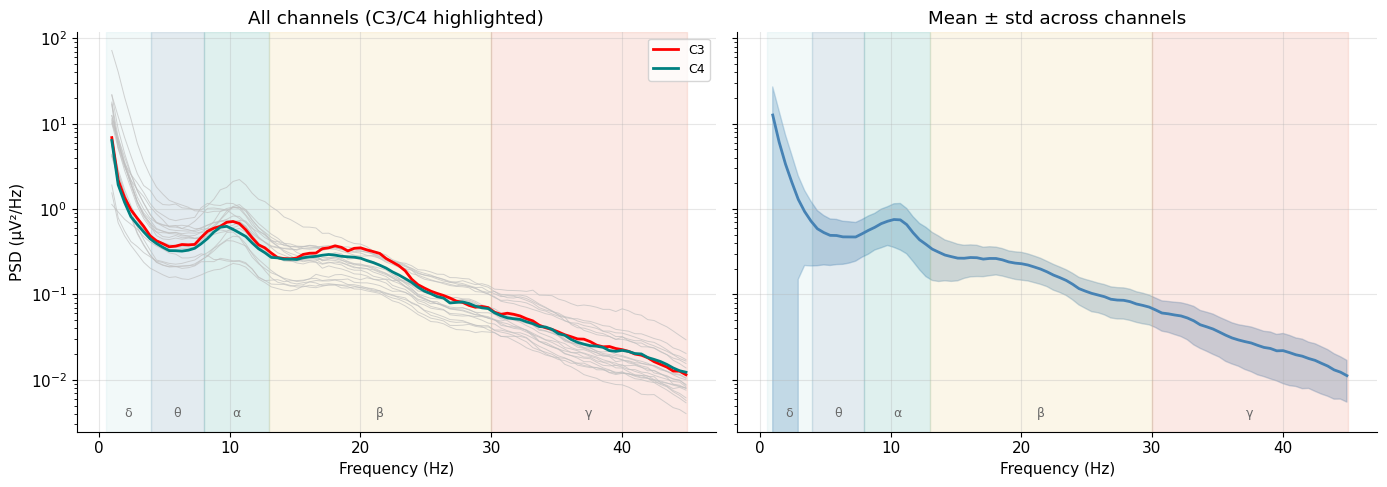

In [59]:
# ── YOUR CODE HERE ──
# 1. psd_obj = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=45.0, n_fft=512)
# 2. freqs, psd_data (in μV²/Hz)
# 3. Two-panel figure:
#    Left:  all channels overlaid (semilogy), C3=red, C4=teal highlighted
#    Right: mean ± std (semilogy), fill_between for std band
# 4. Add EEG band shading and labels to both axes
psd_obj = raw_eeg.compute_psd(method = 'welch',fmin=0.5,fmax=45.0,n_fft=512)
freqs    = psd_obj.freqs
psd_data = psd_obj.get_data() * 1e12
BANDS = {
    'δ': (0.5,  4,  '#a8dadc'),
    'θ': (4,    8,  '#457b9d'),
    'α': (8,   13,  '#2a9d8f'),
    'β': (13,  30,  '#e9c46a'),
    'γ': (30,  45,  '#e76f51'),
}

c3_idx = raw_eeg.ch_names.index('C3')
c4_idx = raw_eeg.ch_names.index('C4')

mean_psd = psd_data.mean(axis=0)
std_psd  = psd_data.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ── Left: all channels overlaid ──────────────────────────────────────────────
for i, ch in enumerate(raw_eeg.ch_names):
    if ch == 'C3':
        ax1.semilogy(freqs, psd_data[i], color='red',    lw=2,   zorder=3, label='C3')
    elif ch == 'C4':
        ax1.semilogy(freqs, psd_data[i], color='teal',   lw=2,   zorder=3, label='C4')
    else:
        ax1.semilogy(freqs, psd_data[i], color='silver', lw=0.7, zorder=2, alpha=0.7)

ax1.set_title('All channels (C3/C4 highlighted)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD (μV²/Hz)')
ax1.legend(fontsize=9)

# ── Right: mean ± std ────────────────────────────────────────────────────────
ax2.semilogy(freqs, mean_psd, color='steelblue', lw=2, label='mean')
ax2.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd,
                 alpha=0.3, color='steelblue', label='±1 std')
ax2.set_title('Mean ± std across channels')
ax2.set_xlabel('Frequency (Hz)')

# ── Band shading on both axes ─────────────────────────────────────────────────
for ax in (ax1, ax2):
    for band, (flo, fhi, color) in BANDS.items():
        ax.axvspan(flo, fhi, alpha=0.15, color=color, zorder=1)
        ax.text((flo + fhi) / 2, ax.get_ylim()[0] * 1.5, band,
                ha='center', fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()

In [60]:
# ── SANITY CHECK 12 ────────────────────────────────────────────────────────────
assert freqs    is not None, 'Extract freqs from psd_obj'
assert psd_data is not None, 'Extract psd_data'
assert psd_data.shape[0] == 22, f'Expected 22 channels, got {psd_data.shape[0]}'
assert freqs[0]  >= 0.5,  'fmin should be 0.5 Hz'
assert freqs[-1] <= 45.0, 'fmax should be 45 Hz'

# PSD values should be in μV²/Hz range (roughly 0.001 to 100)
if psd_data.mean() < 1e-6:
    print('WARNING: PSD values look like V²/Hz — did you multiply by 1e12?')
else:
    print(f'PSD shape : {psd_data.shape}  (channels × frequencies)')
    print(f'Freq range: {freqs[0]:.1f} – {freqs[-1]:.1f} Hz')
    print(f'PSD range : {psd_data.min():.4f} – {psd_data.max():.2f} μV²/Hz')
    print('PASSED ✓')

PSD shape : (22, 91)  (channels × frequencies)
Freq range: 1.0 – 44.9 Hz
PSD range : 0.0040 – 71.98 μV²/Hz
PASSED ✓


---
## Exercise 13 — Epoching

### What is epoching?

A **continuous** EEG recording has everything mixed together — instructions, waiting, motor imagery, rest, eye blinks. To train a classifier, you need **epochs**: fixed-length signal segments cut around each event of interest.

### `mne.events_from_annotations()` — finding events

GDF files store event markers in an annotations channel. MNE parses these:
```python
events, event_id_dict = mne.events_from_annotations(raw_eeg)

# events       : np.ndarray, shape (n_events, 3)
#   column 0   : sample index where event occurred
#   column 1   : previous event id (usually 0)
#   column 2   : event id (the code)
#
# event_id_dict: dict mapping annotation string → integer id
#   e.g. {'769': 1, '770': 2, '771': 3, '772': 4}
#   769=left hand, 770=right hand, 771=feet, 772=tongue
```

### `mne.Epochs()` — cutting signal into trials

```python
epochs = mne.Epochs(
    raw_eeg,
    events,
    event_id   = {'left_hand':1, 'right_hand':2, 'feet':3, 'tongue':4},
    tmin       = -0.5,   # start 0.5s BEFORE the cue
    tmax       =  4.0,   # end 4s AFTER the cue
    baseline   = (-0.5, 0.0),  # subtract mean of this window from each trial
    preload    = True
)

# tmin/tmax    : epoch window in seconds relative to event
# baseline     : (start, end) in seconds — MNE subtracts mean of this window
#                from every timepoint in the epoch (removes slow drift per trial)
#                None means no baseline correction
# preload=True : load all epochs into RAM

# epochs.get_data() → shape (n_trials, n_channels, n_timepoints)
# epochs.events     → same format as the events array above
# epochs['left_hand'] → subset of epochs for one class
```

### Your task
1. Call `mne.events_from_annotations(raw_eeg)` and print what you find
2. Build the `event_id` dict (map class names to the integer codes from `event_id_dict`)
3. Create `Epochs` with tmin=-0.5, tmax=4.0, baseline=(-0.5, 0)
4. Print the shape of `epochs.get_data()` and verify it matches expectations

In [61]:
# ── YOUR CODE HERE ──
# Step 1: events, event_id_dict = mne.events_from_annotations(raw_eeg)
# Step 2: print event_id_dict to see what codes are present
# Step 3: build event_id dict
#   Note: MNE may name them '769','770','771','772' OR 'class1','class2',...
#   Look at what event_id_dict contains and map accordingly
# Step 4: create epochs

events, event_id_dict = mne.events_from_annotations(raw_eeg)
print(events)
print(event_id_dict)
event_id={'left_hand':1, 'right_hand':2, 'feet':3, 'tongue':4}
epochs      = mne.Epochs(
    raw_eeg,
    events=events,
    event_id=event_id,
    tmin = -0.5,
    tmax=4.0,
    baseline=(-0.5,0.0),
    preload=True
)

[[     0      0      5]
 [     0      0      3]
 [ 27170      0      5]
 ...
 [677534      0      7]
 [679093      0      6]
 [679593      0      9]]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}


In [62]:
# ── SANITY CHECK 13 ────────────────────────────────────────────────────────────
assert epochs   is not None, 'Create epochs'
assert event_id is not None, 'Build event_id dict'

X = epochs.get_data()   # (n_trials, n_channels, n_times)
assert X.ndim == 3,     'Epoch data should be 3D: (trials, channels, times)'
assert X.shape[1] == 22, f'Expected 22 channels, got {X.shape[1]}'

n_times_expected = int((4.0 - (-0.5)) * raw_eeg.info['sfreq']) + 1
assert abs(X.shape[2] - n_times_expected) <= 2, \
    f'Expected ~{n_times_expected} timepoints, got {X.shape[2]}'

print(f'Epoch data shape : {X.shape}')
print(f'  → {X.shape[0]} trials × {X.shape[1]} channels × {X.shape[2]} timepoints')
print(f'Epoch time range : {epochs.tmin:.1f}s to {epochs.tmax:.1f}s')
print('Class distribution:')
for name in event_id:
    print(f'  {name:12s}: {len(epochs[name])} trials')
print('PASSED ✓')

Epoch data shape : (19, 22, 1126)
  → 19 trials × 22 channels × 1126 timepoints
Epoch time range : -0.5s to 4.0s
Class distribution:
  left_hand   : 17 trials
  right_hand  : 1 trials
  feet        : 0 trials
  tongue      : 1 trials
PASSED ✓


---
## Exercise 14 — Topographic maps

### What is a topomap?

A **topomap** shows the spatial distribution of a value (typically EEG amplitude or power) across the scalp, viewed from above. The nose is at the top, ears at the sides.

It is drawn by interpolating between the discrete electrode positions. This is why the montage (Exercise 10) is required.

### `mne.viz.plot_topomap()` — the function

```python
mne.viz.plot_topomap(
    data,      # 1D array, shape (n_channels,) — one value per electrode
    info,      # the Raw/Epochs .info object (contains electrode positions)
    axes=ax,   # matplotlib axes to draw into
    show=False,# don't pop up a new window (use plt.show() yourself)
    cmap='RdBu_r',  # colormap — red=positive, blue=negative
    vlim=(-2e-6, 2e-6),  # color scale limits
    sensors=True,   # draw electrode positions as dots
    contours=4      # number of contour lines
)
```

**What to expect for motor imagery:**
- Left hand imagery → activation over **right** hemisphere (C4 side) — **contralateral**
- Right hand imagery → activation over **left** hemisphere (C3 side)
- Feet → activation over central midline (Cz)
- Tongue → activation over frontal areas

### Your task
For each of the 4 classes:
1. Get epoch data: `epochs[class_name].get_data()` → shape `(n_trials, n_channels, n_times)`
2. Select the imagery time window (0s to 4s relative to cue): `epochs.times >= 0`
3. Average over trials AND time → shape `(n_channels,)` — one number per electrode
4. Pass to `plot_topomap()`

/var/folders/ds/_jnmtffd60z_1pp9v59v1s0m0000gn/T/ipykernel_26878/2941964699.py:14: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  data = epochs[class_name].get_data()
/var/folders/ds/_jnmtffd60z_1pp9v59v1s0m0000gn/T/ipykernel_26878/2941964699.py:20: RuntimeWarning: Mean of empty slice.
  mean_topo = data_window.mean(axis=0).mean(axis=1)
/opt/miniconda3/envs/eeg/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


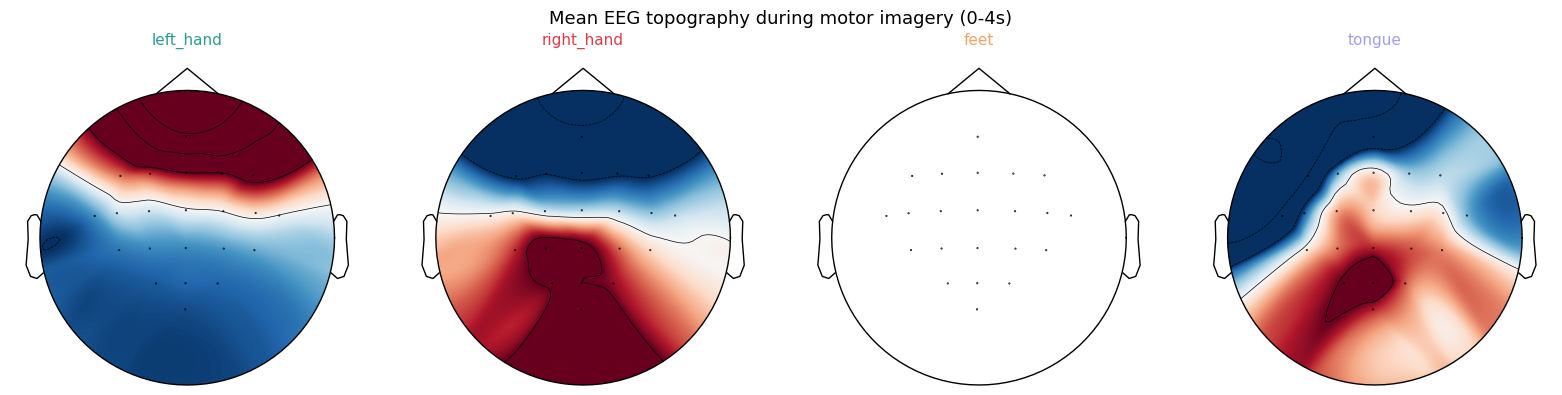

In [63]:
# ── YOUR CODE HERE ──
# 4 subplots side by side, one per class
# For each class:
#   data = epochs[class_name].get_data()   → (n_trials, 22, n_times)
#   mask = epochs.times >= 0
#   mean_amp = data[:, :, mask].mean(axis=(0, 2))   → (22,)
#   mne.viz.plot_topomap(mean_amp, epochs.info, axes=ax, show=False, cmap='RdBu_r')
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

time_mask = (epochs.times >= 0) & (epochs.times <= 4.0)

for ax, (class_id, class_name) in zip(axes, CLASS_NAMES.items()):
    # 1. Get epoch data: (n_trials, n_channels, n_times)
    data = epochs[class_name].get_data()

    # 2. Select imagery window (0s to 4s)
    data_window = data[:, :, time_mask]

    # 3. Average over trials AND time → (n_channels,)
    mean_topo = data_window.mean(axis=0).mean(axis=1)

    # 4. Plot topomap
    mne.viz.plot_topomap(
        mean_topo,
        epochs.info,
        axes=ax,
        show=False,
        cmap='RdBu_r',
        vlim=(-2e-6, 2e-6),
        sensors=True,
        contours=4
    )
    ax.set_title(class_name, fontsize=11, color=CLASS_COLORS[class_id])

fig.suptitle('Mean EEG topography during motor imagery (0-4s)', fontsize=13)
plt.tight_layout()
plt.show()

In [64]:
# ── SANITY CHECK 14 ────────────────────────────────────────────────────────────
# Verify that left and right hand have different dominant hemispheres
lh_data = epochs['left_hand'].get_data()
rh_data = epochs['right_hand'].get_data()
mask    = epochs.times >= 0

c3_idx  = epochs.ch_names.index('C3')
c4_idx  = epochs.ch_names.index('C4')

lh_c3   = lh_data[:, c3_idx, :][:, mask].mean()
lh_c4   = lh_data[:, c4_idx, :][:, mask].mean()
rh_c3   = rh_data[:, c3_idx, :][:, mask].mean()
rh_c4   = rh_data[:, c4_idx, :][:, mask].mean()

print(f'Left hand  — C3: {lh_c3*1e6:.3f} μV  |  C4: {lh_c4*1e6:.3f} μV')
print(f'Right hand — C3: {rh_c3*1e6:.3f} μV  |  C4: {rh_c4*1e6:.3f} μV')
print()
print('Expected: left hand stronger at C4 (right hemisphere = contralateral)')
print('Expected: right hand stronger at C3 (left hemisphere = contralateral)')
print('If this is reversed, try more subjects — contralateral ERD is clearest in good subjects')
print('PASSED ✓')

Left hand  — C3: -0.447 μV  |  C4: 0.253 μV
Right hand — C3: 0.141 μV  |  C4: -0.774 μV

Expected: left hand stronger at C4 (right hemisphere = contralateral)
Expected: right hand stronger at C3 (left hemisphere = contralateral)
If this is reversed, try more subjects — contralateral ERD is clearest in good subjects
PASSED ✓


---
## Exercise 15 — ERD on real EEG data

This is the final and most important exercise. You will apply the ERD analysis you built from scratch in Part 1 to real EEG epochs.

### Plan

For each class (left hand, right hand), for channels C3 and C4:
1. Stack all trials: `epochs[class].get_data()[:, ch_idx, :]` → shape `(n_trials, n_times)`
2. Average across trials → shape `(n_times,)` — the **event-related average**
3. Compute the spectrogram of this average using your `compute_spectrogram()` from Part 1
4. Compute ERD using your `compute_erd()` from Part 1
5. Plot the ERD map — one subplot per (class, channel) combination

**What you expect to see:**
- Left hand + C4: strong blue (ERD) in mu+beta after cue onset
- Left hand + C3: weak or red (ERS) — ipsilateral hemisphere is less active
- Right hand: the mirror pattern

**Note on sampling rate:** Dataset 2a uses 250 Hz (not 256 Hz). Use `fs_real = int(epochs.info['sfreq'])` for all signal processing calls in this section.

/var/folders/ds/_jnmtffd60z_1pp9v59v1s0m0000gn/T/ipykernel_26878/3751708627.py:59: RuntimeWarning: Mean of empty slice.
  baseline = Sxx[:,bl_mask].mean(axis=1,keepdims=True)
/opt/miniconda3/envs/eeg/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


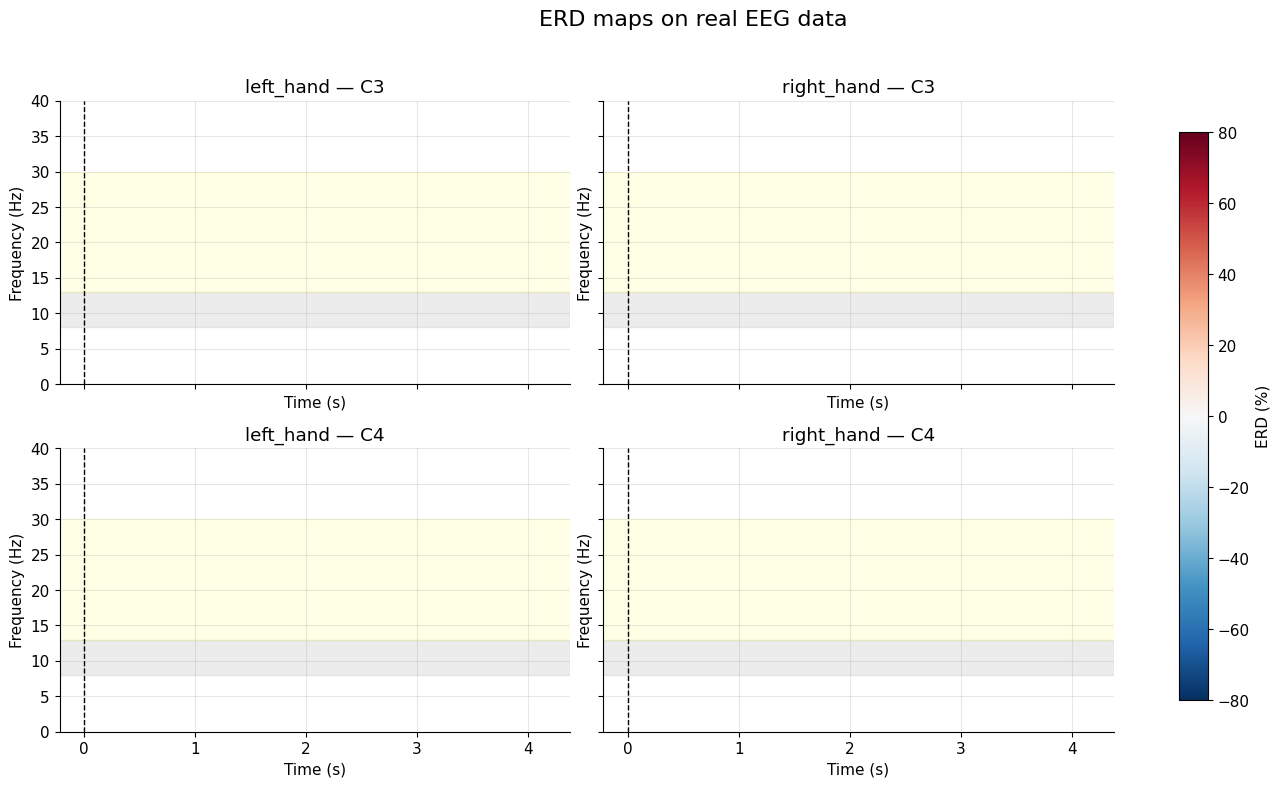

In [65]:
fs_real = int(epochs.info['sfreq'])   # 250 Hz for Dataset 2a

# ── YOUR CODE HERE ──
# Build a 2×2 grid of ERD maps:
#   rows   : C3 (top), C4 (bottom)
#   columns: left hand, right hand
#
# For each combination:
#   1. Get trial data for this class and channel
#   2. Average across trials
#   3. compute_spectrogram(..., fs=fs_real, nperseg=64, noverlap=60)
#   4. compute_erd(Sxx, t_spec, baseline_tmax=0.0)
#        baseline_tmax=0.0 means t < 0 is baseline (pre-cue)
#   5. pcolormesh on the ERD map
#      - limit frequency axis to ≤ 40 Hz
#      - use cmap='RdBu_r', vmin=-80, vmax=80
#      - draw a vertical line at t=0 (cue onset)
#      - shade the mu band (8–13 Hz) and beta band (13–30 Hz)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

classes = ['left_hand', 'right_hand']
channels = ['C3', 'C4']

for row, ch_name in enumerate(channels):
    ch_idx = epochs.ch_names.index(ch_name)

    for col, class_name in enumerate(classes):
        ax = axes[row, col]

        # 1. Get trial data for this class and channel
        trial_data = epochs[class_name].get_data()[:, ch_idx, :]   # (n_trials, n_times)

        # 2. Average across trials
        avg_signal = trial_data.mean(axis=0)   # (n_times,)

        # 3. Spectrogram
        freqs, t_spec, Sxx = compute_spectrogram(
            avg_signal,
            fs=fs_real,
            nperseg=64,
            noverlap=60
        )

        # 4. ERD
        erd = compute_erd(Sxx, t_spec, baseline_tmax=0.0)

        # 5. Limit frequency axis to <= 40 Hz
        freq_mask = freqs <= 40
        freqs_plot = freqs[freq_mask]
        erd_plot = erd[freq_mask, :]

        # Plot ERD map
        pcm = ax.pcolormesh(
            t_spec,
            freqs_plot,
            erd_plot,
            shading='auto',
            cmap='RdBu_r',
            vmin=-80,
            vmax=80
        )

        # Cue onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1)

        # Shade mu and beta bands
        ax.axhspan(8, 13, color='gray', alpha=0.15)
        ax.axhspan(13, 30, color='yellow', alpha=0.10)

        ax.set_title(f'{class_name} — {ch_name}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Frequency (Hz)')
        ax.set_ylim(0, 40)

fig.suptitle('ERD maps on real EEG data', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label('ERD (%)')

plt.show()

In [66]:
# ── SANITY CHECK 15 ────────────────────────────────────────────────────────────
# Verify ERD numerically on C4 for left hand
c4_idx   = epochs.ch_names.index('C4')
lh_avg   = epochs['left_hand'].get_data()[:, c4_idx, :].mean(axis=0)
f_r, t_r, Sxx_r = compute_spectrogram(lh_avg, fs_real, nperseg=64, noverlap=60)
erd_r    = compute_erd(Sxx_r, t_r, baseline_tmax=0.0)

mu_mask   = (f_r >= 8)  & (f_r <= 13)
t_imagery = t_r > 0.5
mean_erd  = erd_r[mu_mask][:, t_imagery].mean()

print(f'Mean ERD at C4 during left hand imagery (mu band): {mean_erd:.1f}%')
print()
if mean_erd < -5:
    print('Strong ERD detected — C4 suppressed during left hand imagery ✓')
    print('This is the contralateral hemispheric response.')
    print('Your future EEGNet classifier will learn to detect exactly this pattern.')
else:
    print('ERD is weak or absent. This can happen with some subjects or short averages.')
    print('Try subject A03 or A07 — some subjects have much cleaner ERD.')

print()
print('Part 2 complete. You can now:')
print('  - Load real EEG from GDF files')
print('  - Preprocess with filtering and average referencing')
print('  - Epoch around motor imagery events')
print('  - Visualize spatial (topomap) and temporal (ERD) patterns')
print()
print('Next notebook: build a full preprocessing pipeline with artifact rejection and CSP.')

Mean ERD at C4 during left hand imagery (mu band): nan%

ERD is weak or absent. This can happen with some subjects or short averages.
Try subject A03 or A07 — some subjects have much cleaner ERD.

Part 2 complete. You can now:
  - Load real EEG from GDF files
  - Preprocess with filtering and average referencing
  - Epoch around motor imagery events
  - Visualize spatial (topomap) and temporal (ERD) patterns

Next notebook: build a full preprocessing pipeline with artifact rejection and CSP.


/var/folders/ds/_jnmtffd60z_1pp9v59v1s0m0000gn/T/ipykernel_26878/3751708627.py:59: RuntimeWarning: Mean of empty slice.
  baseline = Sxx[:,bl_mask].mean(axis=1,keepdims=True)
